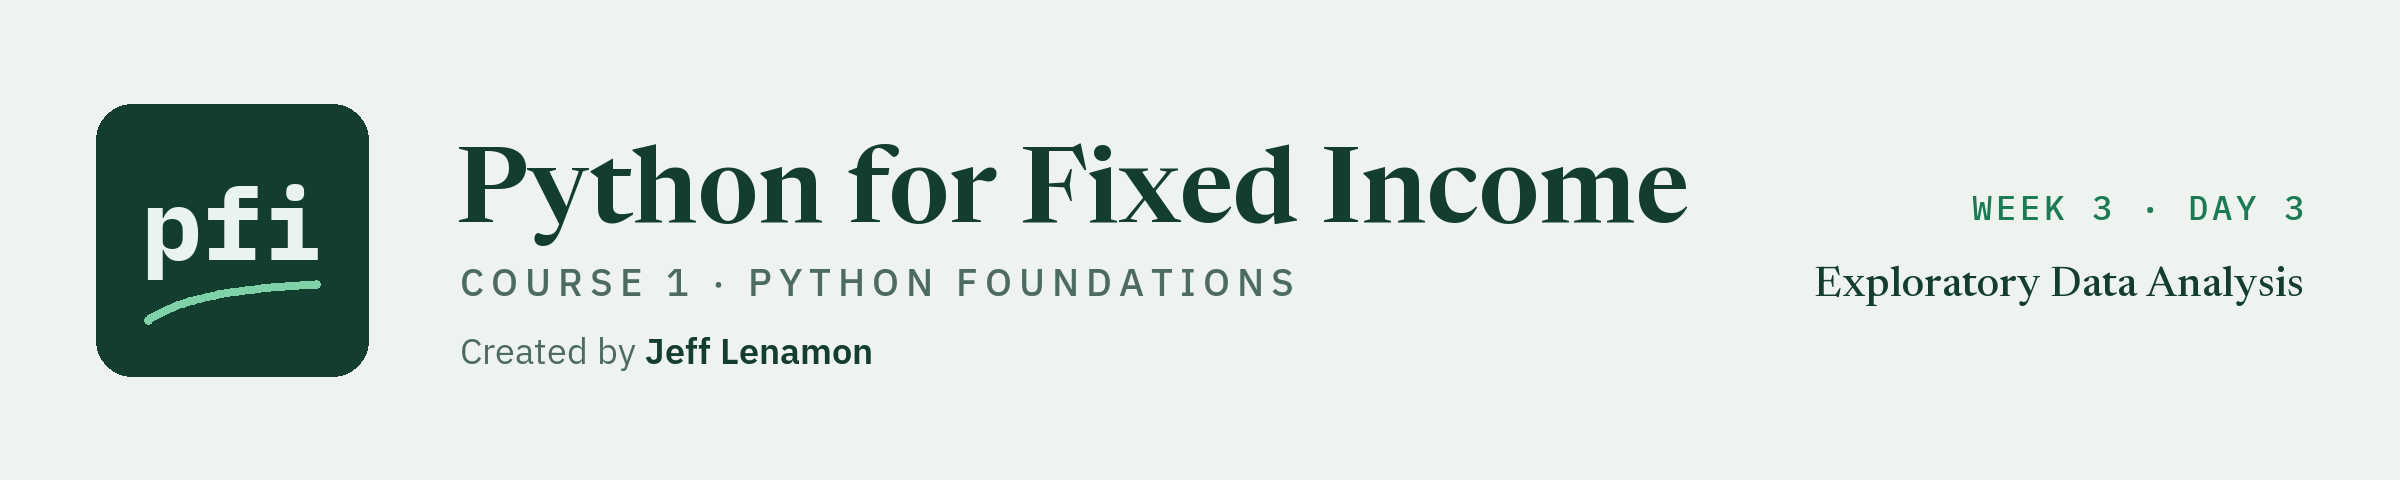

# Exploratory Data Analysis

Week 3. A holdings file arrives with problems in it. Find them by method, decide what to do about each, and show what every decision does to the numbers.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week3/day3/13_exploratory_data_analysis.ipynb)

The operations team has sent the credit desk its month-end extract of the book, as of 2026-09-30. The cover note says three things: **200 bonds, 489,000,000 dollars of face, and a market value of 490,819,215 dollars.** The file is called `holdings_messy.csv`, and the name is fair warning.

The portfolio manager wants three numbers from it for the month-end pack: the market value of the book, its average OAS, and its average yield. You are the desk's analyst. Before any number leaves the desk, your job is to find out whether the file can be trusted, and to fix or flag what cannot.

That work is called **exploratory data analysis**, or EDA: getting to know a table before relying on it. It has a usual order.

1. **Sanity checks.** Is the table the size it should be? Is each column the type it should be? Are there repeated rows, untidy identifiers, or values that cannot be right?
2. **Missing values.** How many, where, and what to do about them.
3. **One column at a time.** The range and shape of each column. This is called univariate analysis.
4. **Outliers.** Values far from the rest, and whether each is an error or a real bond.
5. **Two columns at a time.** How columns move together. This is called bivariate analysis.

Last week's case study gave each table a first look: first rows, shape, data types, summary, missing values, duplicates, and the key. Those files were clean, and every check came back empty. This week's two notebooks drew the charts. Today the routine and the charts are used on a file where the checks do not come back empty.

Three rules for the day:

* **The file as received is never changed.** Every fix is made in a copy.
* **Every fix is a decision.** It is stated, with the evidence for it.
* **Every fix shows its effect.** The headline numbers are printed before and after.

The issuers are invented. Every statement here describes the data, and nothing says a bond or a sector is good or bad.

## 13.1 Setting Up

Q. Import the libraries and check which versions are running.

In [1]:
# os is used to find the data folder
import os

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

print('pandas version:', pd.__version__)
print('numpy version:', np.__version__)
print('matplotlib version:', matplotlib.__version__)
print('seaborn version:', sns.__version__)

pandas version: 3.0.6
numpy version: 2.5.3
matplotlib version: 3.11.2
seaborn version: 0.13.2


* The same libraries as the last two notebooks. This notebook was saved with the versions printed above. Yours may differ, and in Google Colab they may be older.

Q. Load the extract and the rating scale.

In [2]:
# on your own machine the files are in the repo's data folder. In Colab they are read from GitHub.
if os.path.exists('../../../data/holdings_messy.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

# raw is the file exactly as it arrived. Nothing in this notebook changes it.
raw = pd.read_csv(data_folder + 'holdings_messy.csv')
ratings = pd.read_csv(data_folder + 'ratings.csv')

print('raw:', raw.shape)
print('ratings:', ratings.shape)

raw: (204, 19)
ratings: (18, 4)


* 204 rows and 19 columns in the extract, and the 18 rows of the rating scale.
* The cover note said 200 bonds. The first check has already found something.

Q. Store the three figures from the cover note, to check against all day.

In [3]:
# the control totals from the cover note
expected_bonds = 200
expected_face = 489_000_000
expected_value = 490_819_215

print('Expected bonds:', expected_bonds)
print('Expected face:', expected_face, 'dollars')
print('Expected market value:', expected_value, 'dollars')

Expected bonds: 200
Expected face: 489000000 dollars
Expected market value: 490819215 dollars


* Figures like these are called **control totals**: numbers that come from outside the file, which the file should add up to. A file that does not match its control totals is not ready to use.

Q. Write a small function that prints the headline numbers of a table, so that every fix can be measured.

In [4]:
def headline(label, table):
    # the row count, the total market value, and the two averages the portfolio manager asked for
    print(label)
    print('   rows:', len(table))
    print('   market value:', table['market_value'].sum(), 'dollars')
    print('   mean OAS:', round(table['oas'].mean(), 2), 'basis points')
    print('   mean yield:', round(table['yield_pct'].mean(), 3), 'percent')


headline('As received', raw)

As received
   rows: 204
   market value: 497769925.0 dollars
   mean OAS: 187.83 basis points
   mean yield: 6.051 percent


* As received: 204 rows, a market value of 497,769,925 dollars, a mean OAS of 187.83 basis points, and a mean yield of 6.051 percent.
* These are the numbers that would go into the pack if nobody looked. The rest of the notebook finds out how far each one is from the truth.
* Units are as before: `coupon` and `yield_pct` in percent, `oas` in basis points, `duration` in years, `price` per 100 of face, `par_held` and `market_value` in dollars.

## 13.2 Sanity Checks

A sanity check asks a question whose answer is known before looking. How many rows should there be? Can a price be negative? Can one CUSIP appear twice? When the file disagrees with what is known, the file has a problem.

### Size and totals

Q. How does the file compare with the cover note?

In [5]:
# the row count and the two totals, each less the figure in the cover note
print('Rows:', len(raw), ' expected:', expected_bonds, ' difference:', len(raw) - expected_bonds)
print('Face:', raw['par_held'].sum(), ' expected:', expected_face,
      ' difference:', raw['par_held'].sum() - expected_face)
print('Market value:', raw['market_value'].sum(), ' expected:', expected_value,
      ' difference:', raw['market_value'].sum() - expected_value)

Rows: 204  expected: 200  difference: 4
Face: 495500000  expected: 489000000  difference: 6500000
Market value: 497769925.0  expected: 490819215  difference: 6950710.0


* 4 rows too many. The face is 6,500,000 dollars over the cover note and the market value is 6,950,710 dollars over.
* All three differences point the same way: the file holds more than the book does. Extra rows are the first thing to look for.

**Excel side by side.** With the file open in Excel, the same three checks are `=COUNTA(B2:B205)` for the number of bonds, which returns 204, `=SUM(R2:R205)` for the face, and `=SUM(S2:S205)` for the market value, each compared with the cover note. The CUSIP is in column B, the face in column R, and the market value in column S.

### Data types

Q. What type did pandas give each column?

In [6]:
print(raw.dtypes)

as_of_date                str
cusip                     str
ticker                    str
issuer                    str
sector                    str
rating                    str
coupon                float64
maturity                  str
price                 float64
price_date                str
accrued               float64
yield_pct             float64
oas                     int64
duration              float64
spread_duration       float64
dts                   float64
amount_outstanding      int64
par_held                int64
market_value          float64
dtype: object


* Eleven columns are numbers: `float64` for numbers with a decimal point and `int64` for whole numbers. Every column that should be a number is one.
* Eight columns are text, shown as `str`. Older versions of pandas print `object` for text. Five of them are text by nature: the CUSIP, the ticker, the issuer, the sector, and the rating.
* The other three are dates held as text: `as_of_date`, `maturity`, and `price_date`. As last week's case study found, `read_csv` does not turn text into dates unless it is told to.

Does it matter? Ask a date question of a text column.

Q. How many days are there between the oldest and the newest price date in the file?

In [7]:
# the newest price date less the oldest
raw['price_date'].max() - raw['price_date'].min()

TypeError: unsupported operand type(s) for -: 'str' and 'str'

* A `TypeError`, and the last line reads `unsupported operand type(s) for -: 'str' and 'str'`. Python was asked to subtract one piece of text from another, and text has no subtraction.
* `max()` and `min()` did run. Text can be sorted, and dates written as year-month-day sort correctly as text. It was the minus sign that failed.
* Nothing was wrong with the file. The column needs converting before it can do date arithmetic.

Q. Make a working copy of the file and convert its three date columns.

In [8]:
# book is the working copy. Every fix today is made to book, and raw stays as it arrived.
book = raw.copy()

# to_datetime() turns date text into dates
# format= states the layout: four-digit year, month, day, with hyphens
# errors='coerce' turns any text that does not fit the layout into a missing date, in place of an error
for column in ['as_of_date', 'maturity', 'price_date']:
    book[column] = pd.to_datetime(book[column], format='%Y-%m-%d', errors='coerce')
    print(column, '- type:', book[column].dtype, ' dates that could not be read:', book[column].isna().sum())

as_of_date - type: datetime64[us]  dates that could not be read: 0
maturity - type: datetime64[us]  dates that could not be read: 0
price_date - type: datetime64[us]  dates that could not be read: 0


* All three columns are now dates, and none of the values in them failed to convert.
* `errors='coerce'` is a deliberate choice. Without it, one badly typed date stops the conversion with an error. With it, the bad value becomes a missing date and the rest convert. That is only safe if the next line counts the missing dates, as this cell does. A coerce with no count hides problems.
* `isna()` is True where a value is missing, so `isna().sum()` counts the missing values.

Q. Ask the question again.

In [9]:
# a date minus a date is a length of time
print('Oldest price date:', book['price_date'].min().date())
print('Newest price date:', book['price_date'].max().date())
print('Days between them:', (book['price_date'].max() - book['price_date'].min()).days)
print('As-of dates in the file:', book['as_of_date'].nunique())

Oldest price date: 2026-08-04
Newest price date: 2026-09-30
Days between them: 57
As-of dates in the file: 1


* 57 days. The newest price date is 2026-09-30, the as-of date, and the oldest is 2026-08-04.
* That is a finding in itself. A month-end file should be priced at month end. The price dates get their own check later in this section.
* `nunique()` counts the different values in a column. There is one as-of date, as there should be.

**Excel side by side.** Excel has the same split between a number and text that looks like one. `=ISNUMBER(L2)` returns TRUE where the cell holds a number and `=ISTEXT(L2)` returns TRUE where it holds text. A date in Excel is a number with a date format, so `ISNUMBER` returns TRUE for a real date and FALSE for a date typed as text. `=SUMPRODUCT(--ISTEXT(L2:L205))` counts the cells of the yield column that hold text, and returns 0 here.

| Job | pandas | Excel |
| --- | --- | --- |
| Type of each column | `raw.dtypes` | `=ISNUMBER(L2)`, `=ISTEXT(L2)`, one cell at a time |
| Text to a date | `pd.to_datetime(column, format='%Y-%m-%d')` | done by Excel as the CSV opens. `=DATEVALUE(A2)` is for a date still held as text |
| Days between two dates | `(later - earlier).days` | `=later - earlier`, with both cells holding dates |
| Values that would not convert | `column.isna().sum()` after the coerce | `=SUMPRODUCT(--ISTEXT(J2:J205))`, which returns 0 here: a date Excel could not read is left as text |

The dates are where the two tools differ. When Excel opens this CSV it converts the year-month-day text in the three date columns to real dates without asking, so on the opened sheet `=ISNUMBER(J2)` already returns TRUE and `=ISTEXT(J2)` returns FALSE. pandas leaves the text alone until it is told to convert it. `DATEVALUE` is for a date that is still text in its cell, such as a column imported as text. On a cell that already holds a real date it returns `#VALUE!`. The same automatic conversion can mangle identifiers: Excel reads an identifier such as 12345E100 as a number in scientific notation and strips the leading zeros from one such as 00123, which is why a desk checks its identifiers after a CSV has been through Excel.

### Repeated rows

Q. Is any row an exact copy of another? Is any CUSIP there twice?

In [10]:
# duplicated() marks a row True when every value in it matches an earlier row
print('Rows that repeat an earlier row:', book.duplicated().sum())

# on one column, it marks a value True when it has appeared before
print('CUSIPs that repeat an earlier CUSIP:', book['cusip'].duplicated().sum())

Rows that repeat an earlier row: 4
CUSIPs that repeat an earlier CUSIP: 4


* 4 and 4. Four rows are exact copies of earlier rows, and those are the four repeated CUSIPs. No CUSIP is repeated with different values in the other columns, which would be a harder problem.
* 4 is also the number of extra rows against the cover note.

Q. Show the repeated rows next to the rows they repeat.

In [11]:
# keep=False marks every row of a repeated group, the first appearance as well as the copies
copies = book[book.duplicated(keep=False)]

print('Rows shown:', len(copies))
print('Face in the four copies:', book.loc[book.duplicated(), 'par_held'].sum())
print('Market value in the four copies:', book.loc[book.duplicated(), 'market_value'].sum())

copies.sort_values('cusip')[['cusip', 'ticker', 'issuer', 'rating', 'par_held', 'market_value']]

Rows shown: 8
Face in the four copies: 6500000
Market value in the four copies: 6950710.0


,cusip,ticker,issuer,rating,par_held,market_value
18,99009JAC5,CLDB,Calderby Retail,B,250000,244415.0
201,99009JAC5,CLDB,Calderby Retail,B,250000,244415.0
31,99016QAE6,CORY,Corvolvey Systems,BB+,250000,268400.0
202,99016QAE6,CORY,Corvolvey Systems,BB+,250000,268400.0
95,99087JAC0,KRIX,Krilellix Networks,BBB-,4250000,4648905.0
203,99087JAC0,KRIX,Krilellix Networks,BBB-,4250000,4648905.0
15,99103ZAC4,CLAX,Clavulex Industrial,BB-,1750000,1788990.0
200,99103ZAC4,CLAX,Clavulex Industrial,BB-,1750000,1788990.0


* 8 rows: four bonds, each there twice. The row labels show where the copies are. Each original is in the body of the file, and its copy is one of the last four rows, 200 to 203.
* The four copies carry 6,500,000 dollars of face and 6,950,710 dollars of market value. Those are the two differences from the cover note, to the dollar.
* That is the evidence for the decision. The copies are not second holdings of the same bond. They are the same rows sent twice, and they account exactly for the excess over the control totals.

**Decision 1.** Remove the four repeated rows, keeping the first appearance of each.

In [12]:
headline('Before', book)

# drop_duplicates() removes the rows that duplicated() marks, and keeps the first appearance
# reset_index(drop=True) renumbers the rows from 0, so the labels run 0 to 199 with no gaps
book = book.drop_duplicates().reset_index(drop=True)

headline('After', book)
print('Every CUSIP appears once:', book['cusip'].is_unique)
print('Difference from the cover note:', book['market_value'].sum() - expected_value, 'dollars of market value,',
      book['par_held'].sum() - expected_face, 'dollars of face')

Before
   rows: 204
   market value: 497769925.0 dollars
   mean OAS: 187.83 basis points
   mean yield: 6.051 percent
After
   rows: 200
   market value: 490819215.0 dollars
   mean OAS: 185.75 basis points
   mean yield: 6.028 percent
Every CUSIP appears once: True
Difference from the cover note: 0.0 dollars of market value, 0 dollars of face


* 204 rows became 200. The market value went from 497,769,925 to 490,819,215 dollars, and both control totals now match with a difference of zero.
* The mean OAS moved from 187.83 to 185.75 basis points and the mean yield from 6.051 to 6.028 percent. Four repeated rows out of 204 were enough to move an average by 2 basis points, because a repeated bond is counted twice in it.
* `raw` still has 204 rows. Only the copy changed.

**Excel side by side.**

| Job | pandas | Excel |
| --- | --- | --- |
| Is this row's CUSIP repeated? | `book['cusip'].duplicated(keep=False)` | `=COUNTIF($B$2:$B$205, B2) > 1`, filled down |
| How many extra rows? | `book['cusip'].duplicated().sum()` | `=ROWS(B2:B205) - SUMPRODUCT(1 / COUNTIF(B2:B205, B2:B205))` |
| Colour the repeats | | Home, Conditional Formatting, Highlight Cells Rules, Duplicate Values |
| Remove them | `book.drop_duplicates()` | Data, Remove Duplicates |

The `SUMPRODUCT` formula counts the different CUSIPs, 200, and takes that from the 204 rows, which leaves 4. Remove Duplicates deletes the rows in place and reports how many it removed and how many remain. The pandas version returns a new table and leaves the old one alone, which is why `raw` is still there to go back to. In Excel, work on a copy of the sheet for the same reason.

### Identifiers

Q. Is every CUSIP nine characters long?

In [13]:
# str.len() gives the number of characters in each value
print(book['cusip'].str.len().value_counts())

cusip
9    200
Name: count, dtype: int64


* All 200 CUSIPs have 9 characters. In Excel the same check is `=LEN(B2)`, filled down.

Q. How many issuers are in the book, counted by name and counted by ticker?

In [14]:
print('Different issuer names:', book['issuer'].nunique())
print('Different tickers:', book['ticker'].nunique())

Different issuer names: 115
Different tickers: 121


* 115 names and 121 tickers. Each issuer has one ticker, so the two counts should agree. They are 6 apart.

Q. Which issuers have more than one ticker?

In [15]:
# for each issuer name, the number of different tickers among its bonds
tickers_per_issuer = book.groupby('issuer')['ticker'].nunique()
print(tickers_per_issuer[tickers_per_issuer > 1])

# the tickers of one of them. tolist() prints each value in quotes, so that spaces show.
print(book.loc[book['issuer'] == 'Thalundra Aerospace', 'ticker'].tolist())

issuer
Corvulex Logistics     2
Corvundra Brands       2
Feskamyth Insurance    2
Thalundra Aerospace    2
Wyximer Wireless       2
Xanane Foods           2
Name: ticker, dtype: int64
[' thaa ', 'THAA']


* Six issuers have two tickers each. For Thalundra Aerospace the two are `' thaa '` and `'THAA'`: the same four letters, once in lower case with a space on each side.
* To a person those are one ticker. To Python they are two different pieces of text, because a space is a character and `'t'` is not `'T'`.

Q. How many tickers in the file are not four clean capital letters?

In [16]:
# str.strip() removes spaces from both ends of each value, and str.upper() makes the letters capitals
tidy = book['ticker'].str.strip().str.upper()

# the rows where the tidy version differs from what is in the file
untidy = book['ticker'] != tidy
print('Untidy tickers:', untidy.sum())
print(book.loc[untidy, 'ticker'].tolist())

Untidy tickers: 8
['cora', 'CORX ', 'dran', ' elvl ', ' FESH', ' thaa ', 'WYXR ', ' XANE']


* 8 tickers: four with a space at the end or the start, two in lower case, and two with both problems.
* 8 untidy tickers but only 6 issuers with two spellings. The other two, `'dran'` and `' elvl '`, belong to issuers with one bond each, so there was no clean spelling in the file to disagree with. Counting tickers per issuer missed them. Comparing each ticker with its tidy version found all 8.

Q. What does an untidy ticker do to a number?

In [17]:
# market value by ticker, as the column stands
by_ticker = book.groupby('ticker')['market_value'].sum()
print('THAA market value, grouped on the ticker as received:', by_ticker.loc['THAA'])

# the same, grouped on the tidy tickers
by_tidy_ticker = book.groupby(tidy)['market_value'].sum()
print('THAA market value, grouped on the tidy ticker:', by_tidy_ticker.loc['THAA'])
print('Difference:', by_tidy_ticker.loc['THAA'] - by_ticker.loc['THAA'])

THAA market value, grouped on the ticker as received: 2659800.0
THAA market value, grouped on the tidy ticker: 4517617.5
Difference: 1857817.5


* 2,659,800 dollars against 4,517,617.5 dollars. Grouped on the ticker as received, the desk's holding of this issuer is understated by 1,857,817.5 dollars, the bond filed under `' thaa '`. An issuer exposure report built on this column would be wrong with no error raised.

**Decision 2.** Replace every ticker with its tidy version: no spaces at either end, all capitals. The evidence is that each untidy ticker matches a clean one, or the issuer name beside it, once tidied.

In [18]:
# the evidence: each untidy ticker as received, its tidy version, and the issuer beside it
evidence = book.loc[untidy, ['ticker', 'issuer']].copy()
evidence['tidy_ticker'] = tidy[untidy]
# is the tidy version the ticker of another bond in the file?
evidence['on_another_bond'] = evidence['tidy_ticker'].isin(book.loc[~untidy, 'ticker'])
print(evidence)

print('Before - different tickers:', book['ticker'].nunique())

book['ticker'] = book['ticker'].str.strip().str.upper()

print('After  - different tickers:', book['ticker'].nunique(), ' different issuer names:', book['issuer'].nunique())
print('Tickers changed:', untidy.sum())

     ticker                 issuer tidy_ticker  on_another_bond
21     cora       Corvundra Brands        CORA             True
30    CORX      Corvulex Logistics        CORX             True
44     dran  Dralostrin Industrial        DRAN            False
53    elvl          Elvizal Retail        ELVL            False
61     FESH    Feskamyth Insurance        FESH             True
151   thaa     Thalundra Aerospace        THAA             True
186   WYXR        Wyximer Wireless        WYXR             True
189    XANE           Xanane Foods        XANE             True
Before - different tickers: 121
After  - different tickers: 115  different issuer names: 115
Tickers changed: 8


* The table is the evidence. Six of the tidy versions are the ticker of another bond in the file, and in each case that bond has the same issuer. The other two, DRAN and ELVL, belong to issuers with one bond each, and each begins with the first three letters of the issuer name beside it: Dralostrin Industrial and Elvizal Retail.
* 121 tickers became 115, the same as the number of issuer names. 8 values changed and no row was added or removed.
* The three headline numbers do not move, because none of them is grouped by ticker. A fix can matter for one report and not for another.

**Excel side by side.**

| Job | pandas | Excel |
| --- | --- | --- |
| Remove spaces at the ends | `.str.strip()` | `=TRIM(C2)` |
| All capitals | `.str.upper()` | `=UPPER(C2)` |
| First letter of each word a capital | `.str.title()` | `=PROPER(D2)` |
| Both fixes together | `.str.strip().str.upper()` | `=UPPER(TRIM(C2))` |
| Is this ticker untidy? | `book['ticker'] != tidy` | `=NOT(EXACT(C2, UPPER(TRIM(C2))))` |
| How many are untidy? | `untidy.sum()` | `=SUMPRODUCT(--NOT(EXACT(C2:C201, UPPER(TRIM(C2:C201)))))` |

The last formula returns 8. `EXACT` is needed because the `=` sign in Excel does not tell upper case from lower case: `="thaa"="THAA"` is TRUE. `EXACT` does tell them apart. `TRIM` also reduces any run of spaces inside the text to a single space. For the same reason `=COUNTIF(C2:C201, "THAA")` counts `thaa` as well as `THAA`, and still misses any value with a space on the end. Python treats case and spaces as differences everywhere, which is stricter and is why the tidy step comes first.

### Categories

Q. Are the sector names spelled consistently?

In [19]:
# every different value and how often it appears
print(book['sector'].value_counts())

# the same tidy test as for the tickers: no spaces at the ends, a capital at the start of each word
print('Sector names that change when tidied:', (book['sector'] != book['sector'].str.strip().str.title()).sum())

sector
Financials        26
Consumer          26
Materials         26
Telecom           21
Industrials       20
Transportation    20
Health Care       20
Energy            17
Utilities         12
Technology        12
Name: count, dtype: int64
Sector names that change when tidied: 0


* Ten sectors, from 26 bonds each in Financials, Consumer, and Materials down to 12 each in Utilities and Technology, and each name has one spelling. A list like this is where `Energy` and `energy ` would show up as two rows.
* `value_counts()` on a text column is the quickest spelling check there is: read the list, and look for two rows that should be one.

Q. Is every rating one that the rating scale knows?

In [20]:
# isin() is True where the value is one of those in the rating scale
known = book['rating'].isin(ratings['rating'])

print('Ratings found in the scale:', known.sum())
print('Not found:', (~known).sum())

# what the unknown ones are. dropna=False tells value_counts() to count missing values as well.
print(book.loc[~known, 'rating'].value_counts(dropna=False))

Ratings found in the scale: 195
Not found: 5
rating
NaN    5
Name: count, dtype: int64


* 195 ratings are on the scale and 5 are not. The 5 are not misspellings. They are missing: `NaN` is how pandas shows an empty cell.
* By default `value_counts()` leaves missing values out, so a plain `book['rating'].value_counts()` would add up to 195 and say nothing about the gap. `dropna=False` puts them in.
* Missing values get their own section, 13.3.

**Excel side by side.** `=COUNTIF(F2:F201, "BBB-")` counts one rating, and a pivot table with `rating` in Rows and Count of `cusip` in Values lists them all, the same job as `value_counts()`. The test against the scale is `=COUNTIF(ratings!A:A, F2) > 0`, filled down, with the rating scale on a sheet named `ratings`. To stop a wrong rating being typed in the first place, Excel has Data, Data Validation, with Allow set to List and the scale as the source: the cell then accepts only a rating from the list.

### Values that cannot be right

Q. Does any column hold a value that is impossible for a bond?

In [21]:
# each line counts the rows that break one rule. Every count should be zero.
print('Price of zero or less:', (book['price'] <= 0).sum())
print('Coupon of zero or less:', (book['coupon'] <= 0).sum())
print('Duration of zero or less:', (book['duration'] <= 0).sum())
print('Face held of zero or less:', (book['par_held'] <= 0).sum())
print('Maturity on or before the as-of date:', (book['maturity'] <= book['as_of_date']).sum())
print('Face held above the amount outstanding:', (book['par_held'] > book['amount_outstanding']).sum())

Price of zero or less: 0
Coupon of zero or less: 0
Duration of zero or less: 0
Face held of zero or less: 0
Maturity on or before the as-of date: 0
Face held above the amount outstanding: 0


* Zero on all six. No price, coupon, duration, or holding is zero or negative, no bond has already matured, and the desk holds no more of any bond than exists.
* A rule like these needs no judgement: a value either breaks it or does not. Values that are possible and still look wrong come later, in sections 13.4 and 13.5.

Q. Do the columns agree with each other? The market value should be the face times the clean price plus accrued interest, per 100 of face.

In [22]:
# market value worked out from three other columns
worked_out = book['par_held'] * (book['price'] + book['accrued']) / 100

# the gap between that and the market_value column. abs() drops the sign.
gap = (worked_out - book['market_value']).abs()

print('Largest gap:', round(gap.max(), 2), 'dollars')
print('Rows with a gap above 1 dollar:', (gap > 1).sum())

Largest gap: 0.0 dollars
Rows with a gap above 1 dollar: 0


* The largest gap is zero dollars. In all 200 rows the market value is the face times the price plus accrued, divided by 100.
* This check uses no outside knowledge. It asks whether the file agrees with itself. A price changed by hand, or a holding updated without its market value, would show here.

**Excel side by side.** One rule is `=COUNTIF(I2:I201, "<=0")`, which returns 0 for the price in column I. The agreement check is `=MAX(ABS(R2:R201 * (I2:I201 + K2:K201) / 100 - S2:S201))`, with the face in column R, the price in column I, the accrued interest in column K, and the market value in column S. In versions of Excel before dynamic arrays it is entered with Ctrl+Shift+Enter. To make broken rules stand out on the sheet, use Home, Conditional Formatting, Highlight Cells Rules, Less Than, with a value of 0.

### Price dates

The date question earlier found price dates 57 days apart.

Q. Which bonds have a price date before the as-of date?

In [23]:
# the rows whose price is older than the as-of date
stale = book[book['price_date'] < book['as_of_date']]

print('Bonds priced before the as-of date:', len(stale))
print('Their market value:', stale['market_value'].sum(), 'dollars')
print('Share of the book:', round(stale['market_value'].sum() / book['market_value'].sum() * 100, 2), 'percent')

# how many days old each price is
days_old = (stale['as_of_date'] - stale['price_date']).dt.days
print('Days old, least and most:', days_old.min(), 'and', days_old.max())

stale[['cusip', 'ticker', 'rating', 'price', 'price_date', 'market_value']]

Bonds priced before the as-of date: 6
Their market value: 13342347.5 dollars
Share of the book: 2.72 percent
Days old, least and most: 35 and 57


,cusip,ticker,rating,price,price_date,market_value
83,99004EAA5,HLVF,B+,96.683,2026-08-22,1218462.5
86,99012MAC3,HULR,BBB,93.030,2026-08-21,714060.0
124,99131BAB5,PLER,BBB-,98.264,2026-08-26,4977600.0
137,99001BAF3,QVNE,BBB,91.884,2026-08-26,463430.0
187,99118OAC2,WYXR,BB+,103.037,2026-08-04,2387070.0
188,99111HAA8,XANE,BBB,101.036,2026-08-25,3581725.0


* 6 bonds carry a price dated in August, between 35 and 57 days before the as-of date. Together they are 13,342,347.5 dollars of market value, 2.72 percent of the book.
* A price that old is called **stale**. The file cannot say what the price was on 2026-09-30, and nothing in the other columns can supply it.

**Decision 3.** Change nothing, and report the six. An analyst who cannot fix a value from the evidence in hand does not invent one. The six bonds stay in the book at the prices in the file, the table `stale` holds the list, and the report at the end asks the operations team for month-end prices.

**Excel side by side.** `=COUNTIF(J2:J201, "<" & DATE(2026, 9, 30))` counts the price dates before the as-of date and returns 6, where column J holds dates. To see the rows, turn on Data, Filter and use the Date Filters, Before choice on the `price_date` column.

## 13.3 Missing Values

A missing value is a cell with nothing in it. pandas shows it as `NaN`, for not a number, in a column of numbers or text, and as `NaT`, for not a time, in a column of dates. The questions are always the same three: how many, where, and what to do.

Q. How many values are missing in each column?

In [24]:
# isna() is True for each missing cell, and sum() counts the Trues in each column
missing = book.isna().sum()

# only the columns with at least one missing value
print(missing[missing > 0])
print('Missing values in the whole table:', missing.sum())

rating    5
dtype: int64
Missing values in the whole table: 5


* One column has gaps: `rating`, with 5. The other 18 columns are complete.

Q. Which bonds are they, and how much of the book?

In [25]:
# the rows where the rating is missing
unrated = book[book['rating'].isna()]

print('Market value of the five:', unrated['market_value'].sum(), 'dollars')
print('Share of the book:', round(unrated['market_value'].sum() / book['market_value'].sum() * 100, 2), 'percent')
print(unrated['sector'].value_counts())

unrated[['cusip', 'ticker', 'issuer', 'sector', 'coupon', 'oas', 'market_value']]

Market value of the five: 15342537.5 dollars
Share of the book: 3.13 percent
sector
Materials         2
Telecom           1
Industrials       1
Transportation    1
Name: count, dtype: int64


,cusip,ticker,issuer,sector,coupon,oas,market_value
26,99071TAG7,CORL,Corvoquil Metals,Materials,4.000,56,4650820.0
70,99088KAB8,GALX,Galvellix Paper,Materials,7.000,350,4881337.5
105,99077ZAB8,MORX,Morvellix Networks,Telecom,6.125,273,1529605.0
109,99094QAD3,NEVE,Nevane Machinery,Industrials,6.500,113,807900.0
150,99053BAB9,SYLX,Sylvellix Logistics,Transportation,3.625,59,3472875.0


* Five bonds from five issuers, worth 15,342,537.5 dollars, 3.13 percent of the book. Two are in Materials and one each in Telecom, Industrials, and Transportation.
* No pattern stands out. The gaps are not all in one sector or one issuer, and their OAS values run from 56 to 350 basis points, so they are not all one kind of credit. When missing values do cluster, for example all in one sector or all the widest bonds, the cluster is a finding in itself, because whatever is done with the gaps then changes that group more than the others.

**Excel side by side.** `=COUNTBLANK(F2:F201)` counts the empty cells of the rating column and returns 5. To see the rows, turn on Data, Filter, open the list on the `rating` column, and tick only (Blanks). The market value of those rows is `=SUMIF(F2:F201, "", S2:S201)`, which returns 15,342,537.5.

The rating matters for the reports through the rating scale: the score, the bucket, and the grade.

Q. Join the rating scale to the book. What happens to the five?

In [26]:
rows_before = len(book)

# a left merge keeps every bond and looks up its score, bucket, and grade
book = pd.merge(book, ratings, on='rating', how='left')

print('Rows before:', rows_before, ' after:', len(book), ' columns:', book.shape[1])
print(book[['score', 'bucket', 'grade']].isna().sum())

Rows before: 200  after: 200  columns: 22
score     5
bucket    5
grade     5
dtype: int64


* 200 rows before and after, and 22 columns. The five bonds with no rating found no match in the scale, so their score, bucket, and grade are missing too. One gap in the file became four gaps in the table.

**Predict 1**

The `score` column now holds 195 numbers and 5 missing values.

```
book['score'].mean()
```

What does it return?

> A) An error, because the column has missing values.
>
> B) `NaN`, because a sum that includes a missing value is missing.
>
> C) The average of the 195 scores that are there.

Decide, then run the cell.

In [27]:
print('mean():', round(book['score'].mean(), 2))

# count() is the number of values that are not missing. len() is the number of rows.
print('count():', book['score'].count(), ' len():', len(book))

# sum() leaves the missing values out as well
print('sum() divided by count():', round(book['score'].sum() / book['score'].count(), 2))
print('sum() divided by len():', round(book['score'].sum() / len(book), 2))

mean(): 9.35
count(): 195  len(): 200
sum() divided by count(): 9.35
sum() divided by len(): 9.12


* The answer is C. `mean()` returns 9.35, the average of the 195 scores present. pandas leaves missing values out of `mean()`, `sum()`, `median()`, `min()`, `max()`, and `count()`, without a word.
* That is convenient and it is a trap. The 9.35 is the average score of the rated bonds, not of the book. Dividing the same sum by all 200 rows gives 9.12, which is the average of nothing: it treats the five unrated bonds as if their score were zero.
* `count()` and `len()` side by side is the habit. When they differ, an average is being taken over fewer rows than the table has.
* Excel behaves the same way with empty cells. `=AVERAGE(T2:T201)`, with the score in column T of the joined sheet, leaves empty cells out of both the sum and the count. A score looked up with `XLOOKUP` is different: the five unrated rows show `#N/A`, and `AVERAGE` then returns `#N/A` too. `=AGGREGATE(1, 6, T2:T201)` leaves the errors out and averages the 195 scores.

There are four things to do with a missing value. Each one is tried here on a separate table, so that `book` does not change until the decision is made.

Q. Choice 1, leave the gaps as they are. What does the market value by grade add up to?

In [28]:
# market value of each grade
by_grade = book.groupby('grade')['market_value'].sum()
print(by_grade)

print('Sum of the grades:', by_grade.sum())
print('Market value of the book:', book['market_value'].sum())
print('Not in any grade:', book['market_value'].sum() - by_grade.sum())

grade
High Yield          163490907.5
Investment Grade    311985770.0
Name: market_value, dtype: float64
Sum of the grades: 475476677.5
Market value of the book: 490819215.0
Not in any grade: 15342537.5


* Investment Grade 311,985,770 dollars and High Yield 163,490,907.5, which add up to 475,476,677.5. The book is 490,819,215. The split is 15,342,537.5 dollars short, the market value of the five unrated bonds.
* `groupby()` leaves out any row whose group is missing, with no message. A table by grade that does not add up to the book is the usual way a missing rating reaches a report.

Q. Choice 2, drop the rows with a gap. What does that do to the headline numbers?

In [29]:
# dropna() removes rows with a missing value. subset= limits the test to the columns named.
rated_only = book.dropna(subset=['rating'])

headline('All 200 bonds', book)
headline('After dropna()', rated_only)

All 200 bonds
   rows: 200
   market value: 490819215.0 dollars
   mean OAS: 185.75 basis points
   mean yield: 6.028 percent
After dropna()
   rows: 195
   market value: 475476677.5 dollars
   mean OAS: 186.15 basis points
   mean yield: 6.03 percent


* 195 rows. The market value falls by 15,342,537.5 dollars to 475,476,677.5, and no longer matches the control total. The mean OAS rises from 185.75 to 186.15 basis points and the mean yield from 6.028 to 6.03 percent.
* Dropping the rows makes every table add up, by removing five bonds the desk owns. The bonds are real. Only their rating is missing.
* `dropna()` with nothing in the brackets removes every row that has a gap in any column. On a wide table that can remove far more rows than intended.

Q. Choice 3, fill the gaps with a guess. Which rating is the most common, and what happens if the five are given it?

In [30]:
# mode() returns the most common value, or values when there is a tie
print('Most common rating:', book['rating'].mode().tolist())

# fillna() replaces missing values with the value given. Here the guess is BBB-.
guessed = book['rating'].fillna('BBB-')

# look up the grade of each rating, guessed ones included
guessed_grade = pd.merge(guessed.to_frame(), ratings, on='rating', how='left')['grade']
print(guessed_grade.value_counts())

print('Grades as the file stands:')
print(book['grade'].value_counts(dropna=False))

Most common rating: ['A-', 'BBB-']
grade
Investment Grade    130
High Yield           70
Name: count, dtype: int64
Grades as the file stands:
grade
Investment Grade    125
High Yield           70
NaN                   5
Name: count, dtype: int64


* Two ratings tie as the most common, A- and BBB-. A rule that says fill with the most common value has no single answer here, which is a warning about the rule.
* Filling all five with BBB- makes the book 130 Investment Grade bonds and 70 High Yield, in place of 125, 70, and 5 unknown. Every table now adds up and nothing looks missing.
* That is the problem. Five ratings were invented, and no later reader of the table can tell which ones. The five bonds have OAS values from 56 to 350 basis points. They are unlikely to share one rating.

Q. Choice 4, fill the gaps with a label that says what they are.

In [31]:
headline('Before', book)
print('   bonds with no grade:', book['grade'].isna().sum())

# the bucket and the grade of the five become 'Not rated'. The rating and the score stay missing.
book['bucket'] = book['bucket'].fillna('Not rated')
book['grade'] = book['grade'].fillna('Not rated')

headline('After', book)
print('   bonds with no grade:', book['grade'].isna().sum())

by_grade = book.groupby('grade')['market_value'].sum()
print(by_grade)
print('Sum of the grades:', by_grade.sum())

Before
   rows: 200
   market value: 490819215.0 dollars
   mean OAS: 185.75 basis points
   mean yield: 6.028 percent
   bonds with no grade: 5
After
   rows: 200
   market value: 490819215.0 dollars
   mean OAS: 185.75 basis points
   mean yield: 6.028 percent
   bonds with no grade: 0
grade
High Yield          163490907.5
Investment Grade    311985770.0
Not rated            15342537.5
Name: market_value, dtype: float64
Sum of the grades: 490819215.0


* The headline numbers are the same before and after: 200 rows and 490,819,215 dollars. What changed is the split by grade, which now has three rows and adds up to the book: 311,985,770 Investment Grade, 163,490,907.5 High Yield, and 15,342,537.5 Not rated.
* Nothing was invented and nothing was removed. The gap is still a gap, and now it is visible in every table that groups by bucket or grade.
* The `score` was left missing on purpose. It is a number, and there is no honest number to put there. An average score is still an average over 195 bonds, and must be reported as that.

**Decision 4.** Keep the five bonds, label their bucket and grade `Not rated`, and ask for the ratings. The cell above made that change.

| Choice | Code | Rows | Market value in the grade table | What it costs |
| --- | --- | --- | --- | --- |
| Leave | nothing | 200 | 475,476,677.5 | grouped tables come up 15,342,537.5 short, silently |
| Drop | `dropna(subset=['rating'])` | 195 | 475,476,677.5 | five real bonds leave the book, and the control total no longer matches |
| Fill with a guess | `fillna('BBB-')` | 200 | 490,819,215 | five invented ratings that nobody can tell from real ones |
| Fill with a label | `fillna('Not rated')` | 200 | 490,819,215 | one more row in every grouped table |

No choice is right for every column. A missing coupon on a bond with a known issue could be looked up. A missing price might be filled from the day before and flagged. The method is the same each time: try the choice on a copy, print what it does to a total or an average, and write down which one was used.

**Excel side by side.** A pivot table with `grade` in Rows shows the empty cells as their own row, labelled (blank), so the gap is visible by default. `SUMIF` on a named grade leaves them out, as `groupby()` does: `=SUMIF(V2:V201, "Investment Grade", S2:S201) + SUMIF(V2:V201, "High Yield", S2:S201)` returns 475,476,677.5, with the grade in column V of the joined sheet. To fill the empty cells of a column with a label, select the column, press F5, choose Special, then Blanks, type the label, and press Ctrl+Enter.

## 13.4 One Column at a Time

With the structure checked, look at the values. **Univariate analysis** takes one column and asks where its values lie: the lowest and highest, the middle, and the shape. The tools are `describe()` and the histogram of notebook 11.

Q. What is the range of each of the main number columns?

In [32]:
# describe() on six columns, rounded to 2 decimal places
book[['coupon', 'price', 'yield_pct', 'oas', 'duration', 'market_value']].describe().round(2)

,coupon,price,yield_pct,oas,duration,market_value
count,200.00,200.00,200.00,200.00,200.00,200.00
mean,5.94,98.83,6.03,185.75,6.47,2454096.08
std,1.65,7.40,2.04,193.95,3.35,1389340.80
min,3.25,62.04,0.05,19.00,0.93,226417.50
25%,4.75,95.14,5.05,81.75,3.88,1426338.12
50%,5.69,99.42,5.53,135.50,6.31,2295461.25
75%,6.88,103.00,6.39,213.00,8.14,3621396.25
max,11.00,119.13,19.30,1551.00,16.04,5435500.00


Read each column from `min` to `max` and ask whether a bond could have that value.

* `coupon` runs from 3.25 to 11 percent and `duration` from 0.93 to 16.04 years. Nothing odd.
* `price` runs from 62.04 to 119.13. A price of 62 is low and is possible.
* `oas` runs from 19 to 1,551 basis points, with three quarters of the bonds at or below 213. The top of that range is far from the rest.
* `yield_pct` has a minimum of 0.05 percent. The first quartile is 5.05. A corporate bond yielding 0.05 percent, in a book where three quarters of the bonds yield more than 5, needs looking at.

Q. Draw the histogram of the yields.

[0.04706, 0.07308, 4.089, 4.127]


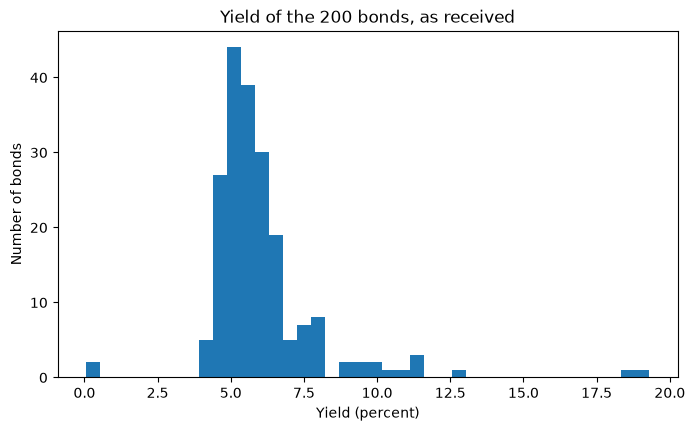

In [33]:
# the four lowest yields, to compare with the chart
print(book['yield_pct'].nsmallest(4).tolist())

fig, ax = plt.subplots(figsize=(8, 4.5))

# 40 bars across the range of the column
ax.hist(book['yield_pct'], bins=40)

ax.set_title('Yield of the 200 bonds, as received')
ax.set_xlabel('Yield (percent)')
ax.set_ylabel('Number of bonds')

plt.show()

* The main crowd is between 4 and about 8 percent, with a thin tail on the right out to 19.
* On the far left, by itself at zero, is one short bar. It holds two bonds, with yields of 0.04706 and 0.07308 percent. The next lowest yield in the book is 4.089 percent.
* `describe()` showed one suspicious number, the minimum. The histogram shows how many bonds are involved and how far they are from the rest. Section 13.5 decides what they are.

Q. For each column, how do the mean and the median compare?

In [34]:
# agg() with a list works out several summaries at once. skew() measures how lopsided a column is.
shape = book[['coupon', 'price', 'yield_pct', 'oas', 'duration', 'dts']].agg(['mean', 'median', 'skew'])

# T turns the table on its side, so that each column of the book is a row
print(shape.T.round(2))

              mean  median  skew
coupon        5.94    5.69  0.99
price        98.83   99.42 -0.71
yield_pct     6.03    5.53  3.07
oas         185.75  135.50  3.93
duration      6.47    6.31  0.50
dts        1133.22  811.00  1.95


* `skew()` is new. It is zero for a column that is the same shape on both sides of its mean, positive when the long tail is on the right, and negative when it is on the left.
* `oas` has the largest skew, 3.93: a long right tail, which pulls the mean, 185.75, well above the median, 135.5. Notebook 11 showed that in a histogram.
* `price` has a negative skew, -0.71. Its tail is on the left, toward the low prices, and its mean, 98.83, is below its median, 99.42.
* `duration` has a skew of 0.5 and its mean and median are close, 6.47 and 6.31 years.
* The pattern from notebook 11 holds across this table: the mean sits on the same side of the median as the long tail. It usually holds. It is a reason to look at a column, not a law.

Q. Draw the two extremes side by side: the price and the OAS, each with its mean and its median.

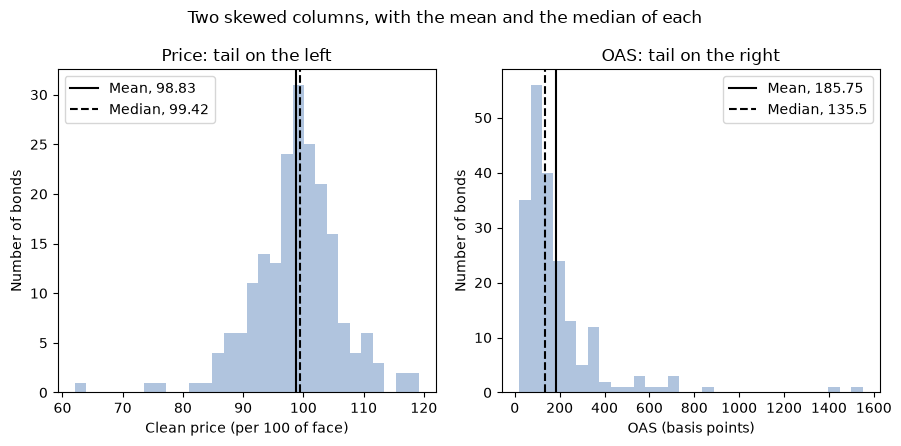

In [35]:
# 1 row and 2 columns of axes on one figure
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))

# the left panel: price
axes[0].hist(book['price'], bins=30, color='lightsteelblue')
axes[0].axvline(book['price'].mean(), color='black', label='Mean, 98.83')
axes[0].axvline(book['price'].median(), color='black', linestyle='--', label='Median, 99.42')
axes[0].set_title('Price: tail on the left')
axes[0].set_xlabel('Clean price (per 100 of face)')
axes[0].set_ylabel('Number of bonds')
axes[0].legend(loc='upper left')

# the right panel: OAS
axes[1].hist(book['oas'], bins=30, color='lightsteelblue')
axes[1].axvline(book['oas'].mean(), color='black', label='Mean, 185.75')
axes[1].axvline(book['oas'].median(), color='black', linestyle='--', label='Median, 135.5')
axes[1].set_title('OAS: tail on the right')
axes[1].set_xlabel('OAS (basis points)')
axes[1].set_ylabel('Number of bonds')
axes[1].legend(loc='upper right')

fig.suptitle('Two skewed columns, with the mean and the median of each')
fig.tight_layout()

plt.show()

* On the left, the prices crowd around 100 and trail away toward 62, and the solid line for the mean is to the left of the dashed line for the median.
* On the right, the OAS values crowd below 250 and trail away toward 1,551, and the mean is to the right of the median.
* On a skewed column, report the median, or report both and say which is which. The portfolio manager asked for the average OAS. The honest pack gives 185.75 as the mean and adds that half the bonds are below 135.5.

For a text column, univariate analysis is a count of each value.

Q. How many bonds are in each rating bucket, with the unrated ones shown?

In [36]:
# the seven buckets in credit order, then the label for the unrated bonds
bucket_order = ratings.sort_values('score')['bucket'].unique().tolist() + ['Not rated']

bucket_counts = book['bucket'].value_counts().loc[bucket_order]
print(bucket_counts)
print('Total:', bucket_counts.sum())

bucket
AAA           2
AA            8
A            53
BBB          62
BB           48
B            17
CCC           5
Not rated     5
Name: count, dtype: int64
Total: 200


* 62 bonds in BBB, 53 in A, and 48 in BB, down to 2 in AAA, with 5 Not rated. The counts add up to 200, because the label put the five back into the table.

**Excel side by side.**

| Job | pandas | Excel | Result |
| --- | --- | --- | --- |
| Lowest yield | `book['yield_pct'].min()` | `=MIN(L2:L201)` | 0.04706 |
| The four lowest | `book['yield_pct'].nsmallest(4)` | `=SMALL(L2:L201, 1)` to `=SMALL(L2:L201, 4)` | 0.04706, 0.07308, 4.089, 4.127 |
| Mean OAS | `book['oas'].mean()` | `=AVERAGE(M2:M201)` | 185.75 |
| Median OAS | `book['oas'].median()` | `=MEDIAN(M2:M201)` | 135.5 |
| Skew of the OAS | `book['oas'].skew()` | `=SKEW(M2:M201)` | 3.93 |
| Bonds in one bucket | `book['bucket'].value_counts()` | `=COUNTIF(U2:U201, "BBB")` | 62 |

The yield is in column L and the OAS in column M, as in the file. The bucket is in column U of the joined sheet. `AVERAGE` against `MEDIAN` in two cells next to each other is the quickest skew check on a sheet: when they are far apart, the column has a tail. The histogram is Insert, Insert Statistic Chart, Histogram.

## 13.5 Outliers

An **outlier** is a value far from the rest of its column. Notebook 11 gave one rule for far: beyond the box plot's whiskers, which is more than 1.5 times the interquartile range past the first or third quartile. The rule is called the IQR rule.

Finding outliers is the easy half. The half that needs an analyst is saying what each one is. There are two kinds:

* an **error**: the value is wrong, and the bond is not really there on the chart;
* a **real extreme**: the value is right, and the bond is unusual.

The rule cannot tell them apart. The other columns can.

Q. Which yields does the IQR rule flag?

In [37]:
# the quartiles and the interquartile range of the yield
q1 = book['yield_pct'].quantile(0.25)
q3 = book['yield_pct'].quantile(0.75)
iqr = q3 - q1

# the limits: one and a half times the IQR beyond each quartile
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

# the rows beyond each limit
low_yield = book['yield_pct'] < lower_limit
high_yield = book['yield_pct'] > upper_limit

print('First quartile:', round(q1, 3), ' third quartile:', round(q3, 3), ' IQR:', round(iqr, 3))
print('Lower limit:', round(lower_limit, 3), ' upper limit:', round(upper_limit, 3))
print('Bonds below the lower limit:', low_yield.sum())
print('Bonds above the upper limit:', high_yield.sum())

First quartile: 5.049  third quartile: 6.39  IQR: 1.341
Lower limit: 3.038  upper limit: 8.401
Bonds below the lower limit: 2
Bonds above the upper limit: 14


* The middle half of the yields lies between 5.049 and 6.39 percent, an IQR of 1.341. The limits are 3.038 and 8.401 percent.
* 2 bonds are below the lower limit and 14 are above the upper limit: 16 flagged out of 200.

Q. Draw the box plot.

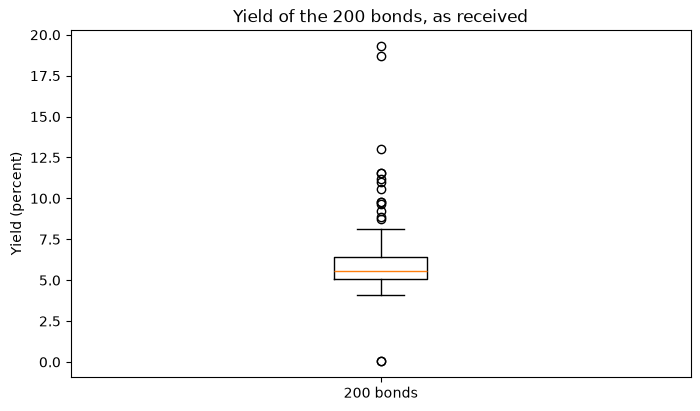

In [38]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# ax.boxplot() takes one column. tick_labels= names the box on the x axis.
ax.boxplot(book['yield_pct'], tick_labels=['200 bonds'])

ax.set_title('Yield of the 200 bonds, as received')
ax.set_ylabel('Yield (percent)')

plt.show()

* The box runs from 5.049 to 6.39, and the circles beyond the whiskers are the 16 flagged bonds: 2 at the bottom near zero, and 14 above the upper whisker, the last two near 19 percent.
* The chart draws all 16 with the same circle. Nothing on it says which are errors.

Start with the two at the bottom.

Q. What do the other columns say about the two lowest yields?

In [39]:
book.loc[low_yield, ['cusip', 'ticker', 'rating', 'coupon', 'maturity', 'price', 'yield_pct', 'oas']]

,cusip,ticker,rating,coupon,maturity,price,yield_pct,oas
123,99143NAD1,PLEA,AA,7.25,2036-02-22,119.131,0.04706,38
152,99109FAA6,THAA,BB,7.00,2049-03-25,96.623,0.07308,275


* A AA bond with a 7.25 percent coupon priced at 119.131, and a BB bond with a 7 percent coupon priced at 96.623. The file gives them yields of 0.04706 and 0.07308 percent.
* The second one settles it without any bond math. A bond priced below 100 yields more than its coupon. This one is priced at 96.623 with a 7 percent coupon, so its yield is above 7 percent. It cannot be 0.07.

A second test uses the OAS. The OAS is the spread over the Treasury curve, so the yield less the OAS is roughly the Treasury yield the bond is measured against. That figure should be similar across the book and cannot be far below zero.

Q. What is the yield less the OAS, for every bond?

In [40]:
# the OAS is in basis points, so divide by 100 to get percent
base = book['yield_pct'] - book['oas'] / 100

print('The two flagged bonds:')
print(base[low_yield].round(3).tolist())

print('The other 198 bonds - lowest:', round(base[~low_yield].min(), 3), ' highest:', round(base[~low_yield].max(), 3))

The two flagged bonds:
[-0.333, -2.677]
The other 198 bonds - lowest: 3.691  highest: 4.585


* For the other 198 bonds the yield less the OAS is between 3.691 and 4.585 percent, a narrow band, as it should be for bonds measured against one Treasury curve on one date.
* For the two flagged bonds it is -0.333 and -2.677 percent. The spread alone is larger than the whole yield. The yields are wrong.

Now look at the numbers themselves: 0.04706 and 0.07308. Read as decimals, they are 4.706 percent and 7.308 percent. Someone entered these two yields as decimals in a column that holds percent.

Q. Does that reading pass the same two tests?

In [41]:
# the two yields multiplied by 100
as_percent = book.loc[low_yield, 'yield_pct'] * 100
print('Read as percent:', as_percent.round(3).tolist())

# the same test as before: yield less OAS
print('Less the OAS:', (as_percent - book.loc[low_yield, 'oas'] / 100).round(3).tolist())

Read as percent: [4.706, 7.308]
Less the OAS: [4.326, 4.558]


* 4.706 and 7.308 percent. Less the OAS they are 4.326 and 4.558 percent, inside the band of 3.691 to 4.585 that the other 198 bonds occupy. The BB bond priced below 100 now yields more than its 7 percent coupon, as it must.

**Predict 2**

The two yields are about 4.7 and 7.2 percentage points too low. The fix will raise them. The mean yield of the 200 bonds is now 6.028 percent and the median is 5.5335.

What does the fix do to the mean and to the median?

> A) Both rise by about the same amount.
>
> B) The mean rises by about 0.06. The median rises by much less.
>
> C) The mean rises by about 0.6. The median does not change.

Decide, then run the cell.

**Decision 5.** Multiply the two yields by 100. The evidence: each is impossible as it stands, on two independent tests, and each passes both tests once read as a decimal.

In [42]:
headline('Before', book)
mean_before = book['yield_pct'].mean()
median_before = book['yield_pct'].median()
print('   median yield:', round(median_before, 4), 'percent')

# multiply the two flagged yields by 100. round(3) keeps three decimal places, like the rest of the column.
book.loc[low_yield, 'yield_pct'] = (book.loc[low_yield, 'yield_pct'] * 100).round(3)

headline('After', book)
print('   median yield:', round(book['yield_pct'].median(), 4), 'percent')
print('   lowest yield:', book['yield_pct'].min(), 'percent')

print('Change in the mean:', round(book['yield_pct'].mean() - mean_before, 4))
print('Change in the median:', round(book['yield_pct'].median() - median_before, 4))

Before
   rows: 200
   market value: 490819215.0 dollars
   mean OAS: 185.75 basis points
   mean yield: 6.028 percent
   median yield: 5.5335 percent
After
   rows: 200
   market value: 490819215.0 dollars
   mean OAS: 185.75 basis points
   mean yield: 6.088 percent
   median yield: 5.547 percent
   lowest yield: 4.089 percent
Change in the mean: 0.0595
Change in the median: 0.0135


* The answer is B. The mean yield rises from 6.028 to 6.088 percent, a change of 0.0595, or about 0.06. The two corrections add about 4.7 and 7.2 points, and their total spread over 200 bonds is 0.06 each.
* The median moves from 5.5335 to 5.547, a change of 0.0135. One of the two yields, now 7.308, crossed from below the middle of the sorted column to above it, which moves the middle along by one bond. The other, now 4.706, was below the middle before and still is. The median does not care how far a value moved, only which side of the middle it is on.
* That is the general lesson about errors and averages. A mean takes in the full size of every error. A median mostly ignores it. A mean that disagrees with what the median suggests is worth a look at the ends of the column.
* The lowest yield in the book is now 4.089 percent. Rows, market value, and mean OAS are unchanged.

Now the 14 at the top.

Q. What do the other columns say about the 14 highest yields?

In [43]:
# the 14 bonds above the upper limit, highest yield first
book.loc[high_yield, ['ticker', 'rating', 'coupon', 'price', 'yield_pct', 'oas']].sort_values('yield_pct', ascending=False)

,ticker,rating,coupon,price,yield_pct,oas
65,FESR,CCC+,10.750,87.116,19.304,1551
17,CLDB,B,9.500,62.045,18.734,1446
132,PRAN,CCC+,10.875,89.407,12.989,871
111,NEVN,B-,10.625,94.053,11.579,719
110,NEVN,B-,11.000,96.616,11.564,720
72,GALX,B-,9.250,87.457,11.193,679
131,PRAN,CCC+,11.000,100.010,10.991,707
66,FESR,CCC+,8.875,87.473,10.601,614
191,XANL,CCC,10.625,104.980,9.793,547
18,CLDB,B,9.250,95.248,9.765,520


* Every one of the 14 is rated B+ or lower, and every OAS is 418 basis points or more. The two highest yields, 19.304 and 18.734 percent, belong to a CCC+ bond and a B bond with OAS values of 1,551 and 1,446.
* The columns agree with each other. A low rating, a wide spread, and a high yield tell one story three times. The yield less the OAS for these bonds was inside the band of the last test.
* These are real extremes. The bonds are in the book, the desk owns them, and their yields are high because their spreads are wide.

Q. Draw the yield against the OAS, with the flagged bonds marked. Use the yields as received, so that the two errors can be seen.

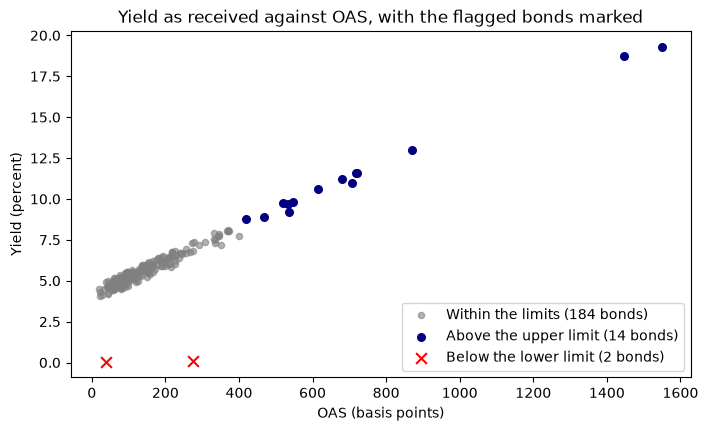

In [44]:
# the yields as they arrived, with the repeated rows removed so that the rows line up with book
received_yield = raw.drop_duplicates().reset_index(drop=True)['yield_pct']

fig, ax = plt.subplots(figsize=(8, 4.5))

# three groups: not flagged, flagged high, flagged low
ax.scatter(book.loc[~low_yield & ~high_yield, 'oas'], received_yield[~low_yield & ~high_yield],
           s=20, alpha=0.6, color='grey', label='Within the limits (184 bonds)')
ax.scatter(book.loc[high_yield, 'oas'], received_yield[high_yield],
           s=30, color='navy', label='Above the upper limit (14 bonds)')
ax.scatter(book.loc[low_yield, 'oas'], received_yield[low_yield],
           s=60, color='red', marker='x', label='Below the lower limit (2 bonds)')

ax.legend(loc='lower right')
ax.set_title('Yield as received against OAS, with the flagged bonds marked')
ax.set_xlabel('OAS (basis points)')
ax.set_ylabel('Yield (percent)')

plt.show()

* 198 points lie along one line: the yield rises with the OAS. The 14 navy points are on that line, at its far end. They are a long way from the crowd and exactly where the rest of the data says they should be.
* The 2 red crosses are off the line, at the bottom of the chart. An error usually breaks a relationship that the real extremes keep.
* This is the practical test for an outlier: look at it against a second column. A box plot of one column could not separate the red from the navy.

The same 14 bonds are the OAS outliers of notebook 11.

Q. Which bonds does the IQR rule flag on OAS, and are they the same 14?

In [45]:
oas_q1 = book['oas'].quantile(0.25)
oas_q3 = book['oas'].quantile(0.75)
oas_upper = oas_q3 + 1.5 * (oas_q3 - oas_q1)

wide = book['oas'] > oas_upper

print('Upper limit for the OAS:', oas_upper)
print('Bonds above it:', wide.sum())
print('Of those, also flagged on yield:', (wide & high_yield).sum())

Upper limit for the OAS: 409.875
Bonds above it: 14
Of those, also flagged on yield: 14


* The upper limit is 409.875 basis points and 14 bonds are above it, as in notebook 11. All 14 are the bonds flagged on yield. Two columns, one set of bonds.

The IQR rule is one way to say far. Another is the **z-score**: how many standard deviations a value is from the mean of its column. The standard deviation measures how far the values of a column typically sit from its mean, in the column's own units. pandas `std()` divides by n minus 1, the same as Excel's `STDEV.S`.

`z = (value - mean) / standard deviation`

Q. Which bonds have an OAS more than 3 standard deviations above the mean?

In [46]:
# std() is the standard deviation of the column
oas_mean = book['oas'].mean()
oas_std = book['oas'].std()

# one z-score for each bond
z = (book['oas'] - oas_mean) / oas_std

print('Mean:', oas_mean, ' standard deviation:', round(oas_std, 2))
print('Bonds with a z-score above 3:', (z > 3).sum())
print('Bonds with a z-score above 2:', (z > 2).sum())
print('Highest z-score:', round(z.max(), 2))

book.loc[z > 3, ['ticker', 'rating', 'oas']]

Mean: 185.75  standard deviation: 193.95
Bonds with a z-score above 3: 3
Bonds with a z-score above 2: 8
Highest z-score: 7.04


,ticker,rating,oas
17,CLDB,B,1446
65,FESR,CCC+,1551
132,PRAN,CCC+,871


* The standard deviation of the OAS is 193.95 basis points. 3 bonds are more than 3 standard deviations above the mean, with OAS values of 1,446, 1,551, and 871. The highest z-score is 7.04.
* The IQR rule flagged 14 and the z-score rule flags 3. Neither is wrong. They are different definitions of far, and the choice of 1.5 or of 3 is a convention.
* The z-score has a weakness on a column like this one. The outliers are part of the mean and the standard deviation they are measured against, and they inflate both. A few very wide bonds raise the bar for all the others. The quartiles of the IQR rule barely move when the tail gets longer.

Some analysts, and some code, remove outliers as a cleaning step.

**Predict 3**

The mean OAS of the book is 185.75 basis points. Suppose the 14 bonds above the IQR limit are deleted.

What happens to the mean OAS?

> A) It falls by less than 5 basis points. 14 bonds out of 200 is 7 percent of the rows.
>
> B) It falls by about 40 basis points.
>
> C) It does not change. The outliers were not part of the average.

Decide, then run the cell.

In [47]:
# a separate table without the 14 bonds. book is not changed.
trimmed = book[~wide]

headline('All 200 bonds', book)
headline('Without the 14 widest', trimmed)

print('Fall in the mean OAS:', round(book['oas'].mean() - trimmed['oas'].mean(), 2), 'basis points')
print('Median OAS, all 200:', book['oas'].median(), ' without the 14:', trimmed['oas'].median())
print('Market value removed:', book.loc[wide, 'market_value'].sum(), 'dollars')
print('Share of the book:', round(book.loc[wide, 'market_value'].sum() / book['market_value'].sum() * 100, 2), 'percent')

All 200 bonds
   rows: 200
   market value: 490819215.0 dollars
   mean OAS: 185.75 basis points
   mean yield: 6.088 percent
Without the 14 widest
   rows: 186
   market value: 459945087.5 dollars
   mean OAS: 144.21 basis points
   mean yield: 5.67 percent
Fall in the mean OAS: 41.54 basis points
Median OAS, all 200: 135.5  without the 14: 125.5
Market value removed: 30874127.5 dollars
Share of the book: 6.29 percent


* The answer is B. The mean OAS falls from 185.75 to 144.21 basis points, a drop of 41.54. Seven percent of the rows carried over a fifth of the mean.
* The median falls from 135.5 to 125.5. The mean yield falls from 6.088 to 5.67 percent.
* The table would also lose 30,874,127.5 dollars of market value, 6.29 percent of the book, and no longer match the control total.
* The result is a tidy table that describes a portfolio the desk does not own. The widest bonds are the part of a credit book a risk report most needs to show.

**Decision 6.** Keep all 14. They are real, the other columns confirm them, and they stay in every number. **A row is never deleted because it is far away.** It is corrected if it is an error and the right value is known, flagged if it is an error and the right value is not known, and kept if it is real.

**Excel side by side.**

| Job | pandas | Excel | Result |
| --- | --- | --- | --- |
| First quartile of the yield | `book['yield_pct'].quantile(0.25)` | `=QUARTILE.INC(L2:L201, 1)` | 5.049 |
| Third quartile | `book['yield_pct'].quantile(0.75)` | `=QUARTILE.INC(L2:L201, 3)` | 6.39 |
| Upper limit | `q3 + 1.5 * iqr` | `=QUARTILE.INC(L2:L201, 3) + 1.5 * (QUARTILE.INC(L2:L201, 3) - QUARTILE.INC(L2:L201, 1))` | 8.401 |
| Bonds below the lower limit | `low_yield.sum()` | `=COUNTIF(L2:L201, "<3.038")` | 2 |
| Standard deviation of the OAS | `book['oas'].std()` | `=STDEV.S(M2:M201)` | 193.95 |
| z-score of one bond | `(value - mean) / std` | `=STANDARDIZE(M2, AVERAGE(M$2:M$201), STDEV.S(M$2:M$201))` | |
| Bonds with a z-score above 3 | `(z > 3).sum()` | `=COUNTIF(M2:M201, ">" & AVERAGE(M2:M201) + 3 * STDEV.S(M2:M201))` | 3 |

The yield results are for the column as received, before the fix. To make the flagged cells stand out on the sheet, select the yield column and use Home, Conditional Formatting, Highlight Cells Rules, Less Than, with 3.038 as the value. A second rule with Greater Than and 8.401 marks the other end. A sheet shows flagged cells well. Deciding what each one is takes the same look across the row as it does here.

## 13.6 Two Columns at a Time

**Bivariate analysis** takes two columns and asks whether they move together. The tools are the correlation and the scatter plot from notebook 11, and the group-by. It does two jobs in EDA: it describes the book, and, as the last chart showed, it catches errors that one column alone cannot.

Q. How do the main number columns correlate with each other?

In [48]:
# corr() on a table gives the correlation of every pair of its columns
book[['coupon', 'price', 'yield_pct', 'oas', 'duration']].corr().round(2)

,coupon,price,yield_pct,oas,duration
coupon,1.00,0.31,0.74,0.74,-0.05
price,0.31,1.00,-0.32,-0.30,-0.19
yield_pct,0.74,-0.32,1.00,0.99,0.01
oas,0.74,-0.30,0.99,1.00,-0.11
duration,-0.05,-0.19,0.01,-0.11,1.00


* Yield and OAS have a correlation of 0.99: across this file they are almost one column, which is what the straight line in the last chart showed.
* Coupon correlates at 0.74 with both the yield and the OAS, as in notebook 12.
* Duration is close to zero against everything: -0.11 with the OAS and 0.01 with the yield.

Q. What did the two wrong yields do to the correlation of yield and OAS?

In [49]:
# received_yield is the yield column before the fix, from section 13.5
print('With the two yields as received:', round(received_yield.corr(book['oas']), 2))
print('With the two yields corrected:', round(book['yield_pct'].corr(book['oas']), 2))

With the two yields as received: 0.95
With the two yields corrected: 0.99


* 0.95 as received and 0.99 corrected. Two rows out of 200 moved the correlation by 0.04. A correlation is built from means, and like a mean it takes in the full size of every error.
* A correlation that is lower than the desk expects is a reason to draw the scatter plot and look for points off the line.

A correlation near zero does not always mean two columns are unrelated. Notebook 11 found that duration and OAS tilt opposite ways in the two grades. Duration and yield show 0.01 for the whole book.

Q. What is the correlation of duration and yield within each grade?

In [50]:
print('All 200 bonds:', round(book['duration'].corr(book['yield_pct']), 2))

# the same correlation on the bonds of one grade at a time
for grade in ['Investment Grade', 'High Yield']:
    part = book[book['grade'] == grade]
    print(grade, '-', len(part), 'bonds:', round(part['duration'].corr(part['yield_pct']), 2))

All 200 bonds: 0.01
Investment Grade - 125 bonds: 0.61
High Yield - 70 bonds: 0.0


* 0.01 for the book, 0.61 across the 125 Investment Grade bonds, and 0.0 across the 70 High Yield bonds.
* Within Investment Grade, the longer bonds in this file have the higher yields, and clearly so. Across High Yield there is no such tilt. Put together in one cloud, the relationship disappears.
* The 5 Not rated bonds are left out of the loop. A correlation across 5 points says very little.

Q. Draw the two grades side by side.

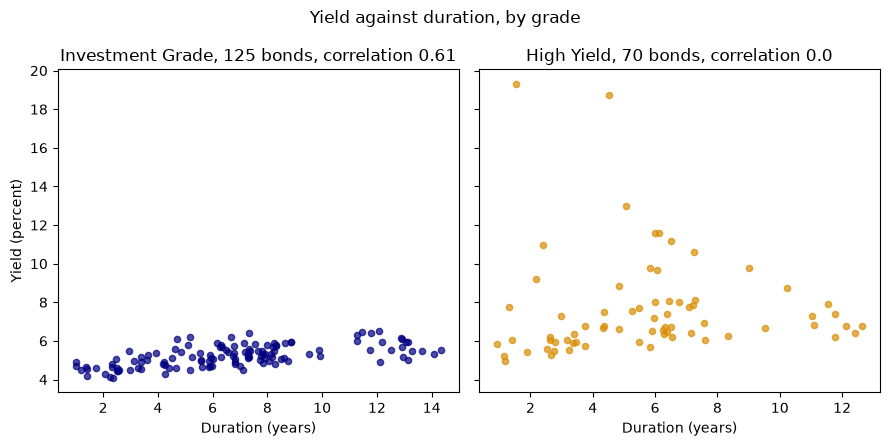

In [51]:
# two panels with a shared y axis, so that heights can be compared across them
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5), sharey=True)

ig = book[book['grade'] == 'Investment Grade']
hy = book[book['grade'] == 'High Yield']

axes[0].scatter(ig['duration'], ig['yield_pct'], s=20, alpha=0.7, color='navy')
axes[0].set_title('Investment Grade, 125 bonds, correlation 0.61')
axes[0].set_xlabel('Duration (years)')
axes[0].set_ylabel('Yield (percent)')

axes[1].scatter(hy['duration'], hy['yield_pct'], s=20, alpha=0.7, color='#d98e04')
axes[1].set_title('High Yield, 70 bonds, correlation 0.0')
axes[1].set_xlabel('Duration (years)')

fig.suptitle('Yield against duration, by grade')
fig.tight_layout()

plt.show()

* On the left, the Investment Grade bonds form a narrow band that rises from short to long. On the right, the High Yield bonds are scattered from about 5 to 19 percent at every duration, with no tilt.
* The y axis is shared, which shows a second fact: the whole Investment Grade band fits inside the bottom of the High Yield panel.
* This describes one invented file on one date. It is not a statement about what any bond should yield.

The last pairing is a number against a category.

Q. Where do the five Not rated bonds sit against the rated buckets?

           count  median  min   max
bucket                             
AAA            2    21.0   19    23
AA             8    38.5   22    57
A             53    76.0   44   151
BBB           62   126.5   66   204
BB            48   217.5  125   367
B             17   418.0  236  1446
CCC            5   707.0  547  1551
Not rated      5   113.0   56   350


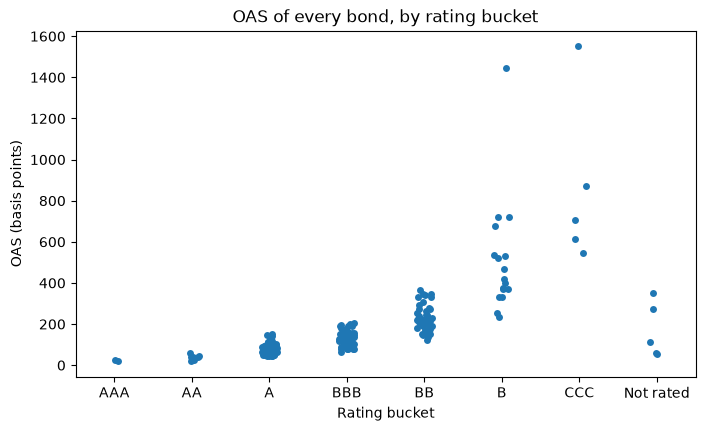

In [52]:
# the count and the median OAS of each bucket, in credit order with Not rated last
print(book.groupby('bucket')['oas'].agg(['count', 'median', 'min', 'max']).loc[bucket_order])

# a strip plot has random jitter, so fix the seed
np.random.seed(0)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.stripplot(data=book, x='bucket', y='oas', order=bucket_order, ax=ax)

ax.set_title('OAS of every bond, by rating bucket')
ax.set_xlabel('Rating bucket')
ax.set_ylabel('OAS (basis points)')

plt.show()

* The median OAS rises with each step down the scale, from 21 basis points for AAA to 707 for CCC.
* The five Not rated bonds run from 56 to 350 basis points, with a median of 113. The two tightest are 56 and 59: 56 is inside the ranges of both AA and A, and 59 is inside the range of A. The widest, 350, is inside the ranges of both BB and B.
* That spread is the case against filling the five with one guessed rating, made with the data. It is also not a way to assign them ratings: the columns overlap, and a spread level is consistent with several buckets.

**Excel side by side.**

| Job | pandas | Excel | Result |
| --- | --- | --- | --- |
| Correlation of two columns | `book['yield_pct'].corr(book['oas'])` | `=CORREL(L2:L201, M2:M201)` | 0.99 |
| Every pair at once | `book[columns].corr()` | one `CORREL` for each pair | |
| Correlation within a grade | filter, then `.corr()` | `=CORREL(FILTER(N2:N201, V2:V201 = "Investment Grade"), FILTER(L2:L201, V2:V201 = "Investment Grade"))` | 0.61 |
| Median OAS of one bucket | `book.groupby('bucket')['oas'].median()` | `=MEDIAN(FILTER(M2:M201, U2:U201 = "Not rated"))` | 113 |

The duration is in column N, the yield in column L, and the OAS in column M. The bucket and the grade are in columns U and V of the joined sheet. `FILTER` is in Excel 365 and Excel 2021. Hiding rows with Data, Filter does not change what `CORREL` returns: it uses every cell in the range it is given, hidden or not, which is why the formula does the filtering itself.

## 13.7 What the Desk Reports

The exploring is done. Before the report is written, the corrected table is checked one last time: against the cover note, and against a second file.

Q. How do the headline numbers compare, as received and as corrected?

In [53]:
headline('As received', raw)
headline('As corrected', book)

print('As received less as corrected:')
print('   market value:', raw['market_value'].sum() - book['market_value'].sum(), 'dollars')
print('   mean OAS:', round(raw['oas'].mean() - book['oas'].mean(), 2), 'basis points')
print('   mean yield:', round(raw['yield_pct'].mean() - book['yield_pct'].mean(), 3), 'percent')

print('Difference from the cover note:')
print('   bonds:', len(book) - expected_bonds)
print('   face:', book['par_held'].sum() - expected_face, 'dollars')
print('   market value:', book['market_value'].sum() - expected_value, 'dollars')

As received
   rows: 204
   market value: 497769925.0 dollars
   mean OAS: 187.83 basis points
   mean yield: 6.051 percent
As corrected
   rows: 200
   market value: 490819215.0 dollars
   mean OAS: 185.75 basis points
   mean yield: 6.088 percent
As received less as corrected:
   market value: 6950710.0 dollars
   mean OAS: 2.08 basis points
   mean yield: -0.037 percent
Difference from the cover note:
   bonds: 0
   face: 0 dollars
   market value: 0.0 dollars


* As received: 204 rows, 497,769,925 dollars, a mean OAS of 187.83 basis points, and a mean yield of 6.051 percent.
* As corrected: 200 rows, 490,819,215 dollars, 185.75 basis points, and 6.088 percent. All three control totals match with a difference of zero.
* The market value was overstated by 6,950,710 dollars and the mean OAS by 2.08 basis points, both from the repeated rows. The mean yield was understated by 0.037 percent: the two wrong yields pulled it down by more than the repeated rows pushed it up.

The course repo also holds `holdings.csv`, the same book as the operations team should have sent it. Until now this notebook has not looked at it. It is the test of the day's work.

Q. Does the corrected table match the clean file?

In [54]:
# the clean file, with its three date columns read as dates
clean = pd.read_csv(data_folder + 'holdings.csv', parse_dates=['as_of_date', 'maturity', 'price_date'])

print('Rows - corrected:', len(book), ' clean:', len(clean))
print('Market value - corrected:', book['market_value'].sum(), ' clean:', clean['market_value'].sum())
print('Mean OAS - corrected:', book['oas'].mean(), ' clean:', clean['oas'].mean())
print('Mean yield - corrected:', round(book['yield_pct'].mean(), 3), ' clean:', round(clean['yield_pct'].mean(), 3))
print('Same CUSIPs in the same order:', (book['cusip'] == clean['cusip']).all())

# for each column of the clean file, count the rows where the corrected table differs
print('Columns that differ, and in how many rows:')
for column in clean.columns:
    different = (book[column] != clean[column]).sum()
    if different > 0:
        print('  ', column, different)

Rows - corrected: 200  clean: 200
Market value - corrected: 490819215.0  clean: 490819215.0
Mean OAS - corrected: 185.75  clean: 185.75
Mean yield - corrected: 6.088  clean: 6.088
Same CUSIPs in the same order: True
Columns that differ, and in how many rows:
   rating 5
   price_date 6


* The same 200 CUSIPs in the same order, the same market value of 490,819,215 dollars, the same mean OAS of 185.75, and the same mean yield of 6.088 percent.
* Of the 19 columns, 17 match the clean file in every row. That includes the ticker, where 8 values were tidied, and the yield, where 2 were corrected: both fixes landed on the values in the clean file.
* Two columns differ, and they are the two that were reported and not fixed: `rating` in 5 rows and `price_date` in 6. The evidence in the file could not supply those values, and the corrected table does not pretend otherwise.

Q. What were the five missing ratings?

In [55]:
# the rows of the clean file where the corrected table has no rating
answers = clean.loc[book['rating'].isna(), ['cusip', 'ticker', 'rating']]
answers = pd.merge(answers, ratings, on='rating', how='left')
print(answers[['cusip', 'ticker', 'rating', 'grade']])
print(answers['grade'].value_counts())

       cusip ticker rating             grade
0  99071TAG7   CORL     A-  Investment Grade
1  99088KAB8   GALX     B-        High Yield
2  99077ZAB8   MORX    BB-        High Yield
3  99094QAD3   NEVE     A-  Investment Grade
4  99053BAB9   SYLX     A+  Investment Grade
grade
Investment Grade    3
High Yield          2
Name: count, dtype: int64


* A-, B-, BB-, A-, and A+: three Investment Grade bonds and two High Yield. None of the five is BBB-. The guess in section 13.3 would have been wrong on every rating and would have put two High Yield bonds into Investment Grade.
* On a desk there is no clean file to check against. The control totals, the tests of one column against another, and the written decisions are what stand in for it.

**The report to the desk**

| # | Finding | How it was found | Bonds | What was done | Effect |
| --- | --- | --- | --- | --- | --- |
| 1 | Rows sent twice | row count against the cover note, `duplicated()` | 4 | removed the copies | market value down 6,950,710 dollars to match the control total, mean OAS 187.83 to 185.75 |
| 2 | Tickers with spaces or lower case | `nunique()` of ticker against issuer, comparison with `.str.strip().str.upper()` | 8 | tidied | 121 tickers became 115, issuer totals now complete |
| 3 | Prices dated in August | date arithmetic on `price_date` | 6 | flagged, not changed | 13,342,347.5 dollars, 2.72 percent of the book, at prices 35 to 57 days old |
| 4 | Ratings missing | `isna().sum()` | 5 | labelled Not rated, kept | 15,342,537.5 dollars, 3.13 percent of the book, shown as its own row |
| 5 | Yields entered as decimals | `describe()`, histogram, IQR rule, yield less OAS | 2 | multiplied by 100 | mean yield 6.028 to 6.088 percent |
| 6 | Very wide spreads | IQR rule and z-scores on OAS | 14 | kept: real bonds | none. They carry 41.54 basis points of the 185.75 mean OAS |

The five widest of the 14, by OAS: 1,551, 1,446, 871, 720, and 719 basis points.

**For the month-end pack:** a market value of 490,819,215 dollars across 200 bonds, a mean OAS of 185.75 basis points with a median of 135.5, and a mean yield of 6.088 percent.

**Open with the operations team:** month-end prices for 6 bonds, ratings for 5 bonds, and the reason 4 rows were sent twice.

The problems in `holdings_messy.csv` were put there for this lesson. The full list is in `data/holdings_messy_answer_key.md` in the course repo, and it matches the six findings above.

## 13.8 Make It Repeatable

The extract is a month-end file, so another one arrives next month. Today's decisions are spread over seven sections of this notebook, between charts and experiments. To be run again they have to be in one place, in order, with the checks attached.

Q. Write the day's decisions as one function that takes the file as received and returns the cleaned table.

In [56]:
def clean_holdings(raw, ratings):
    """Apply the day's decisions to the extract as received and return the cleaned table.

    raw is the holdings extract and ratings is the rating scale. Neither is changed.
    """
    # work on a copy, so the table as received stays as it arrived
    book = raw.copy()

    # the three date columns become dates, and a date that cannot be read stops the function
    for column in ['as_of_date', 'maturity', 'price_date']:
        book[column] = pd.to_datetime(book[column], format='%Y-%m-%d', errors='coerce')
        assert book[column].notna().all(), f'{column} holds a date that could not be read'

    # decision 1: remove the rows sent twice, keeping the first appearance of each
    book = book.drop_duplicates().reset_index(drop=True)

    # decision 2: tidy the tickers
    book['ticker'] = book['ticker'].str.strip().str.upper()

    # decision 3: the stale prices are reported and not changed, so there is no line for them

    # decision 4: join the rating scale, then label the bonds with no rating
    book = pd.merge(book, ratings, on='rating', how='left', validate='many_to_one')
    book['bucket'] = book['bucket'].fillna('Not rated')
    book['grade'] = book['grade'].fillna('Not rated')

    # decision 5: a yield below the lower limit of the IQR rule was entered as a decimal, so it is multiplied by 100
    q1 = book['yield_pct'].quantile(0.25)
    q3 = book['yield_pct'].quantile(0.75)
    entered_as_decimal = book['yield_pct'] < q1 - 1.5 * (q3 - q1)
    book.loc[entered_as_decimal, 'yield_pct'] = (book.loc[entered_as_decimal, 'yield_pct'] * 100).round(3)

    # decision 6: the very wide bonds are real, and they stay

    return book


# the whole day in one line
rebuilt = clean_holdings(raw, ratings)

print(f'Rows in: {len(raw):,}   rows out: {len(rebuilt):,}   columns out: {rebuilt.shape[1]}')
print(f'Same as the table built step by step today: {rebuilt.equals(book)}')
print(f'Rows in raw after the call: {len(raw):,}')

Rows in: 204   rows out: 200   columns out: 22
Same as the table built step by step today: True
Rows in raw after the call: 204


* 204 rows in, 200 rows and 22 columns out. `equals()` returns True: the table the function returns has the same values, in the same rows and columns, as the `book` that took all day to build.
* The function holds the fixes in the order they were made, with one comment for each decision. Decisions 3 and 6 changed nothing, and they are still there as comments, so that a reader can see they were considered.
* It takes `raw` and `ratings` as arguments and returns a new table. It uses nothing else from the notebook around it, which means it can be lifted out. Notebook 19, on week 4 day 4, moves a function like this one into a `.py` file that any notebook can import.
* `validate='many_to_one'` on the merge, from week 2, stops the function if a rating ever appears twice in the scale.
* The function records this month's evidence. Next month's file can have problems this one did not, so the function is where the work starts, and the checks in the next cell say whether it was enough.

Q. Check the cleaned table against the three control totals, with checks that stop.

In [57]:
bonds = len(rebuilt)
face = rebuilt['par_held'].sum()
market_value = rebuilt['market_value'].sum()

# each assert stops the notebook, with its message, if the table does not match the cover note
assert bonds == expected_bonds, f'{bonds:,} bonds, and the cover note says {expected_bonds:,}'
assert face == expected_face, f'{face:,} dollars of face, and the cover note says {expected_face:,}'

# a total of decimal numbers is compared with np.isclose(), which allows for the tiny error of decimal arithmetic
assert np.isclose(market_value, expected_value), f'{market_value:,.2f} dollars of market value, and the cover note says {expected_value:,}'

print(f'Bonds: {bonds:,}')
print(f'Face: {face:,} dollars')
print(f'Market value: {market_value:,.2f} dollars')
print('All three control totals match the cover note.')

Bonds: 200
Face: 489,000,000 dollars
Market value: 490,819,215.00 dollars
All three control totals match the cover note.


* 200 bonds, 489,000,000 dollars of face, and 490,819,215.00 dollars of market value. All three `assert` lines passed, so the cell ran to its last line.
* An `assert`, from week 1, is a check that stops. When the condition is True nothing happens. When it is False the notebook stops with an `AssertionError` and the message after the comma.
* The messages are f-strings that hold both numbers, the one found and the one expected, so the error says what is wrong and by how much.

The same first check, asked of the file as it arrived:

In [58]:
# the first control total, on the table as received
assert len(raw) == expected_bonds, f'{len(raw):,} bonds, and the cover note says {expected_bonds:,}'

AssertionError: 204 bonds, and the cover note says 200

* An `AssertionError`, and the last line is the message written into the check: 204 bonds, and the cover note says 200.
* This morning the same fact was a printed line, `difference: 4`, and it relied on someone reading it. An `assert` does not rely on a reader. In a run on next month's file nothing after this line would execute, and no number built on a wrong table would reach the pack.
* That is the rule from week 1: a check that matters is an `assert`, not a printed number. Print as well, for the reader. Assert, for the run nobody watches.

Q. Write the decisions down as a table.

In [59]:
# one row for each decision: the problem, the number of rows it touched, and what was done
# the counts come from the tables and the True and False columns built during the day, so none is typed
decision_log = pd.DataFrame({
    'problem': ['Rows sent twice', 'Tickers with spaces or lower case', 'Prices dated before the as-of date',
                'Ratings missing', 'Yields entered as decimals', 'Very wide spreads'],
    'rows': [len(raw) - len(rebuilt), untidy.sum(), len(stale),
             rebuilt['rating'].isna().sum(), low_yield.sum(), wide.sum()],
    'decision': ['removed the copies', 'tidied', 'flagged, not changed',
                 'kept, labelled Not rated', 'multiplied by 100', 'kept: real bonds'],
})

print(f'Decisions: {len(decision_log)}   rows changed or removed: {decision_log.loc[[0, 1, 4], "rows"].sum()}')
decision_log

Decisions: 6   rows changed or removed: 14


,problem,rows,decision
0,Rows sent twice,4,removed the copies
1,Tickers with spaces or lower case,8,tidied
2,Prices dated before the as-of date,6,"flagged, not changed"
3,Ratings missing,5,"kept, labelled Not rated"
4,Yields entered as decimals,2,multiplied by 100
5,Very wide spreads,14,kept: real bonds


* Six decisions: 4, 8, 6, 5, 2, and 14 rows. Three of them changed the table, removing 4 rows and correcting 10 values, 14 rows in all. The other three flagged or kept what was there.
* It is the report of section 13.7 as a DataFrame. That table was typed by hand. This one is built by code from the day's results, so on next month's file the counts fill themselves in.
* A decision log travels with the cleaned table. Whoever uses the table can see what was done to it without opening this notebook.

Q. Save the cleaned table and the log as one Excel workbook with two sheets, read it back, and tidy up.

In [60]:
report_file = 'holdings_clean_2026-09-30.xlsx'

# ExcelWriter, from week 2, holds a workbook open while each table is written to its own sheet
# index=False leaves the row labels out of the sheet
with pd.ExcelWriter(report_file) as writer:
    rebuilt.to_excel(writer, sheet_name='holdings', index=False)
    decision_log.to_excel(writer, sheet_name='decisions', index=False)

print(f'File exists: {os.path.exists(report_file)}')

# sheet_name=None reads every sheet, into a dictionary of tables with the sheet names as keys
sheets = pd.read_excel(report_file, sheet_name=None)
for name, table in sheets.items():
    print(f'Sheet {name}: {len(table):,} rows, {table.shape[1]} columns')

# what came back, against what was written
back = sheets['holdings']
print(f'Market value read back: {back["market_value"].sum():,.2f} dollars')
print(f'Type of the maturity column read back: {back["maturity"].dtype}')
print(f'Ratings missing, read back: {back["rating"].isna().sum()}')

# os.remove() deletes the file, so the folder is left as it was found
os.remove(report_file)
print(f'File exists after removing it: {os.path.exists(report_file)}')

File exists: True
Sheet holdings: 200 rows, 22 columns
Sheet decisions: 6 rows, 3 columns
Market value read back: 490,819,215.00 dollars
Type of the maturity column read back: datetime64[us]
Ratings missing, read back: 5
File exists after removing it: False


* One workbook with two sheets: `holdings`, 200 rows and 22 columns, and `decisions`, 6 rows and 3 columns. Read back, the market value is 490,819,215.00 dollars, the dates are still dates, and the 5 missing ratings are still missing.
* The cleaned table went to a new file with its own name. The file as received was never written over, which is the first rule of the day carried through to the end.
* The file was written to the working folder, read back, and deleted. In your own work, leave out the `os.remove()` line and the workbook stays.
* Writing `.xlsx` files needs the `openpyxl` library, which is in `requirements.txt` and is already installed in Google Colab.

**Excel side by side.** The workbook opens in Excel with two sheet tabs, `holdings` and `decisions`, each with its header row in row 1. The three date columns arrive as real dates, so `=ISNUMBER(A2)` returns TRUE on the `holdings` sheet. They carry a date and time format that is wider than a new column, so they show as `########` until the column is widened. The values are intact. `=SUM(S2:S201)` returns 490,819,215, and the five unrated bonds have an empty `rating` cell and `Not rated` in the `bucket` and `grade` columns.

| Job | pandas | Excel |
| --- | --- | --- |
| The same steps on next month's file | a function, `clean_holdings(raw, ratings)` | a Power Query query: Data, Get Data, From File, From Text/CSV, Transform Data. Each step is listed under Applied Steps, and Refresh runs them again |
| A check against a control total | `assert bonds == expected_bonds, 'message'` | a check cell: `=IF(COUNTA(B2:B201) = 200, "ok", "CHECK: row count")` |
| Two tables in one file | `pd.ExcelWriter` and `sheet_name=` | two sheets in one workbook |
| Read one sheet | `pd.read_excel(file, sheet_name='decisions')` | click the sheet tab |

The check cell returns `ok` on the `holdings` sheet. It shows its result and does not stop anything, so it belongs where it will be read, at the top of the sheet.

## You Can Now

* Check a file against control totals: the row count and the sums it should add up to.
* Find columns of dates held as text, convert them with `pd.to_datetime()`, and count what would not convert.
* Find repeated rows with `duplicated()` and remove them with `drop_duplicates()`.
* Find untidy text with `.str.strip()` and `.str.upper()`, and inconsistent categories with `value_counts()` and `isin()`.
* Count missing values with `isna().sum()`, and say what leaving, dropping, and filling each do to a total.
* Describe one column with `describe()`, the mean against the median, and `skew()`.
* Flag outliers with the IQR rule and with z-scores, and use a second column to tell an error from a real extreme.
* Compare two columns with `corr()` and a scatter plot, for the whole table and within groups.
* Make every fix in a copy, state it as a decision, and print the headline numbers before and after.
* Package the decisions as one function, check its result with `assert` against the control totals, keep a decision log, and write both to an Excel workbook with two sheets.
* Match each step to Excel: `COUNTBLANK`, `COUNTIF`, `TRIM`, `UPPER`, `EXACT`, `ISNUMBER`, `QUARTILE.INC`, `STANDARDIZE`, `SKEW`, `CORREL`, Remove Duplicates, Data Validation, and Conditional Formatting.

The next notebook is a case study. It applies the same order of work to Treasury yields by tenor and year.

## Exercises

The exercises use the same extract and ask about columns and cuts the lesson did not examine: the price, the sectors, the DTS, and the coupon. The issuers are invented, and every answer describes the data and is not a view.

Replace each `...` with your own code, then run the check cell. Exercise 5 asks for a function that builds on `clean_holdings`. Print the numbers you rely on, and where an exercise asks for a chart, give it a title and axis labels with units. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It imports the libraries, defines `check`, a small function that marks your answers, loads a fresh `raw`, defines `clean_holdings` as in section 13.8, and builds `book` again by calling it. It prints the shape of `raw`, (204, 19), the shape of `book`, (200, 22), and the market value of the book, 490819215.0.

In [61]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    # ... is the placeholder, and None is what a function returns before its body is written
    if answer is ... or answer is None:
        print(label + ': not attempted yet')
        return
    if isinstance(expected, list):
        # a list of values: the same values in the same order
        correct = list(answer) == expected
    elif isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


# fresh copies of the two files. In Colab they are read from GitHub.
if os.path.exists('../../../data/holdings_messy.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

raw = pd.read_csv(data_folder + 'holdings_messy.csv')
ratings = pd.read_csv(data_folder + 'ratings.csv')

# the function of section 13.8: the lesson's decisions in one place
def clean_holdings(raw, ratings):
    """Apply the day's decisions to the extract as received and return the cleaned table.

    raw is the holdings extract and ratings is the rating scale. Neither is changed.
    """
    # work on a copy, so the table as received stays as it arrived
    book = raw.copy()

    # the three date columns become dates, and a date that cannot be read stops the function
    for column in ['as_of_date', 'maturity', 'price_date']:
        book[column] = pd.to_datetime(book[column], format='%Y-%m-%d', errors='coerce')
        assert book[column].notna().all(), f'{column} holds a date that could not be read'

    # decision 1: remove the rows sent twice, keeping the first appearance of each
    book = book.drop_duplicates().reset_index(drop=True)

    # decision 2: tidy the tickers
    book['ticker'] = book['ticker'].str.strip().str.upper()

    # decision 3: the stale prices are reported and not changed, so there is no line for them

    # decision 4: join the rating scale, then label the bonds with no rating
    book = pd.merge(book, ratings, on='rating', how='left', validate='many_to_one')
    book['bucket'] = book['bucket'].fillna('Not rated')
    book['grade'] = book['grade'].fillna('Not rated')

    # decision 5: a yield below the lower limit of the IQR rule was entered as a decimal, so it is multiplied by 100
    q1 = book['yield_pct'].quantile(0.25)
    q3 = book['yield_pct'].quantile(0.75)
    entered_as_decimal = book['yield_pct'] < q1 - 1.5 * (q3 - q1)
    book.loc[entered_as_decimal, 'yield_pct'] = (book.loc[entered_as_decimal, 'yield_pct'] * 100).round(3)

    # decision 6: the very wide bonds are real, and they stay

    return book


book = clean_holdings(raw, ratings)

print(raw.shape)
print(book.shape)
print(book['market_value'].sum())

(204, 19)
(200, 22)
490819215.0


### Exercise 1

Q. Apply the IQR rule to the `price` column of `book`. What are the lower and upper limits, and how many bonds are below the lower limit and above the upper limit? Store the two counts in **ex1_below** and **ex1_above**. Then look at the rating and the OAS of the flagged bonds, and say whether they look like errors or real extremes.

In [62]:
ex1_below = ...
ex1_above = ...

In [63]:
check('Exercise 1 below the lower limit', ex1_below, 4)
check('Exercise 1 above the upper limit', ex1_above, 4)

Exercise 1 below the lower limit: not attempted yet
Exercise 1 above the upper limit: not attempted yet


### Exercise 2

Q. Suppose the five bonds with no rating were dropped with `dropna(subset=['rating'])`. Work out the market value of each sector before and after. Which sector loses the most market value, and how many dollars does it lose? Store the answers in **ex2_sector** and **ex2_lost**.

In [64]:
ex2_sector = ...
ex2_lost = ...

In [65]:
check('Exercise 2 sector', ex2_sector, 'Materials')
check('Exercise 2 dollars lost', ex2_lost, 9532157.5)

Exercise 2 sector: not attempted yet
Exercise 2 dollars lost: not attempted yet


### Exercise 3

Q. Describe the `dts` column of `book` on its own. Work out its mean and its median, each rounded to 2 decimal places, and store them in **ex3_mean** and **ex3_median**. Then work out a z-score for each bond's DTS and count the bonds with a z-score above 3. Store the count in **ex3_count**. Draw the histogram with the mean and the median marked.

In [66]:
ex3_mean = ...
ex3_median = ...
ex3_count = ...

In [67]:
check('Exercise 3 mean', ex3_mean, 1133.22)
check('Exercise 3 median', ex3_median, 811.0)
check('Exercise 3 count', ex3_count, 6)

Exercise 3 mean: not attempted yet
Exercise 3 median: not attempted yet
Exercise 3 count: not attempted yet


### Exercise 4

Q. What is the correlation of `coupon` and `price` across all 200 bonds, across the Investment Grade bonds, and across the High Yield bonds? Round each to 2 decimal places and store them in **ex4_all**, **ex4_ig**, and **ex4_hy**. Draw the two grades as two scatter plots side by side.

In [68]:
ex4_all = ...
ex4_ig = ...
ex4_hy = ...

In [69]:
check('Exercise 4 all bonds', ex4_all, 0.31)
check('Exercise 4 Investment Grade', ex4_ig, 0.81)
check('Exercise 4 High Yield', ex4_hy, 0.07)

Exercise 4 all bonds: not attempted yet
Exercise 4 Investment Grade: not attempted yet
Exercise 4 High Yield: not attempted yet


### Exercise 5

The lesson reported the six stale prices and changed nothing. A flag is easier to act on when it travels with the table, as a column.

Q. Write a function, `clean_and_flag(raw, ratings)`, that extends the day's cleaning. It calls `clean_holdings`, then adds a column named `stale_price` that is True where the price date is before the as-of date. Before it returns the table, it checks with an `assert` and a message that no CUSIP appears twice. Call it on `raw` and store the result in **ex5_book**.

In [70]:
def clean_and_flag(raw, ratings):
    """Clean the extract with clean_holdings, flag the stale prices, and check the CUSIPs. Return the table."""
    ...


ex5_book = clean_and_flag(raw, ratings)

In [71]:
if ex5_book is None:
    check('Exercise 5 table', ex5_book, None)
else:
    check('Exercise 5 columns', ex5_book.shape[1], 23)
    check('Exercise 5 stale prices flagged', int(ex5_book['stale_price'].sum()), 6)

    # a file with one CUSIP on two rows that differ: the first row again, with another face amount
    broken = pd.concat([raw, raw.head(1).assign(par_held=1_000)], ignore_index=True)

    # the function should stop on it. try and except, from week 1, catch the error so the check can report it.
    try:
        clean_and_flag(broken, ratings)
        stopped = False
    except AssertionError as error:
        stopped = True
        print('Stopped with the message:', error)
    check('Exercise 5 the assert stops a repeated CUSIP', stopped, True)

Exercise 5 table: not attempted yet


### Exercise 6: AI check

You ask an AI assistant to load the extract, clean it, and report the number of bonds, the market value, and the mean OAS. It gives you the code below. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug.

Q. Read the code before you run it. What should the three numbers be? The lesson worked them out, and two of them are on the cover note. Then run the code. Does the answer agree with you?

In [72]:
# written for this course in the style of an AI assistant's answer. It contains one bug.
# load the extract
data = pd.read_csv(data_folder + 'holdings_messy.csv')

# remove repeated rows
data = data.drop_duplicates()

# remove incomplete rows
data = data.dropna()

ex6_bonds = len(data)
ex6_value = data['market_value'].sum()
ex6_oas = round(data['oas'].mean(), 2)

print('Bonds:', ex6_bonds)
print('Market value:', ex6_value, 'dollars')
print('Mean OAS:', ex6_oas, 'basis points')

Bonds: 195
Market value: 475476677.5 dollars
Mean OAS: 186.15 basis points


Q. Find the bug and fix the code in the cell above, so that **ex6_bonds**, **ex6_value**, and **ex6_oas** hold the right answers.

In [73]:
check('Exercise 6 bonds', ex6_bonds, 200)
check('Exercise 6 market value', ex6_value, 490819215.0)
check('Exercise 6 mean OAS', ex6_oas, 185.75)

Exercise 6 bonds: not yet. You have 195
Exercise 6 market value: not yet. You have 475476677.5
Exercise 6 mean OAS: not yet. You have 186.15
